In [ ]:
import os
import pandas as pd
import librosa
import re
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# RAVDESS

## EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_ravdess = pd.read_csv('/content/drive/MyDrive/df_ravdess_normv3full.csv')

In [ ]:
df_ravdess.columns.to_list()

['modality',
 'vocal_channel',
 'emotion',
 'intensity',
 'statement',
 'repetition',
 'actor_id',
 'gender',
 'F0semitoneFrom27.5Hz_sma3nz_amean',
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
 'loudness_sma3_amean',
 'loudness_sma3_stddevNorm',
 'loudness_sma3_percentile20.0',
 'loudness_sma3_percentile50.0',
 'loudness_sma3_percentile80.0',
 'loudness_sma3_pctlrange0-2',
 'loudness_sma3_meanRisingSlope',
 'loudness_sma3_stddevRisingSlope',
 'loudness_sma3_meanFallingSlope',
 'loudness_sma3_stddevFallingSlope',
 'spectralFlux_sma3_amean',
 'spectralFlux_sma3_stddevNorm',
 'mfcc1_sma3_amean',
 'mfcc1_sma3_stdde

In [ ]:
df_ravdess.gender.value_counts()

,count
gender,
male,528
female,484


In [ ]:
df_ravdess.shape

(1012, 157)

In [ ]:
df_ravdess.emotion.value_counts()

,count
emotion,
3,184
5,184
4,184
6,184
2,184
1,92


In [ ]:
import pandas as pd

# Creates a matrix of actor_id vs. emotion counts
distribution = pd.crosstab(df_ravdess['actor_id'], df_ravdess['emotion'])

print(distribution)

emotion   1  2  3  4  5  6
actor_id                  
1         4  8  8  8  8  8
2         4  8  8  8  8  8
3         4  8  8  8  8  8
4         4  8  8  8  8  8
5         4  8  8  8  8  8
6         4  8  8  8  8  8
7         4  8  8  8  8  8
8         4  8  8  8  8  8
9         4  8  8  8  8  8
10        4  8  8  8  8  8
11        4  8  8  8  8  8
12        4  8  8  8  8  8
13        4  8  8  8  8  8
14        4  8  8  8  8  8
15        4  8  8  8  8  8
16        4  8  8  8  8  8
17        4  8  8  8  8  8
19        4  8  8  8  8  8
20        4  8  8  8  8  8
21        4  8  8  8  8  8
22        4  8  8  8  8  8
23        4  8  8  8  8  8
24        4  8  8  8  8  8


<Figure size 1400x800 with 0 Axes>

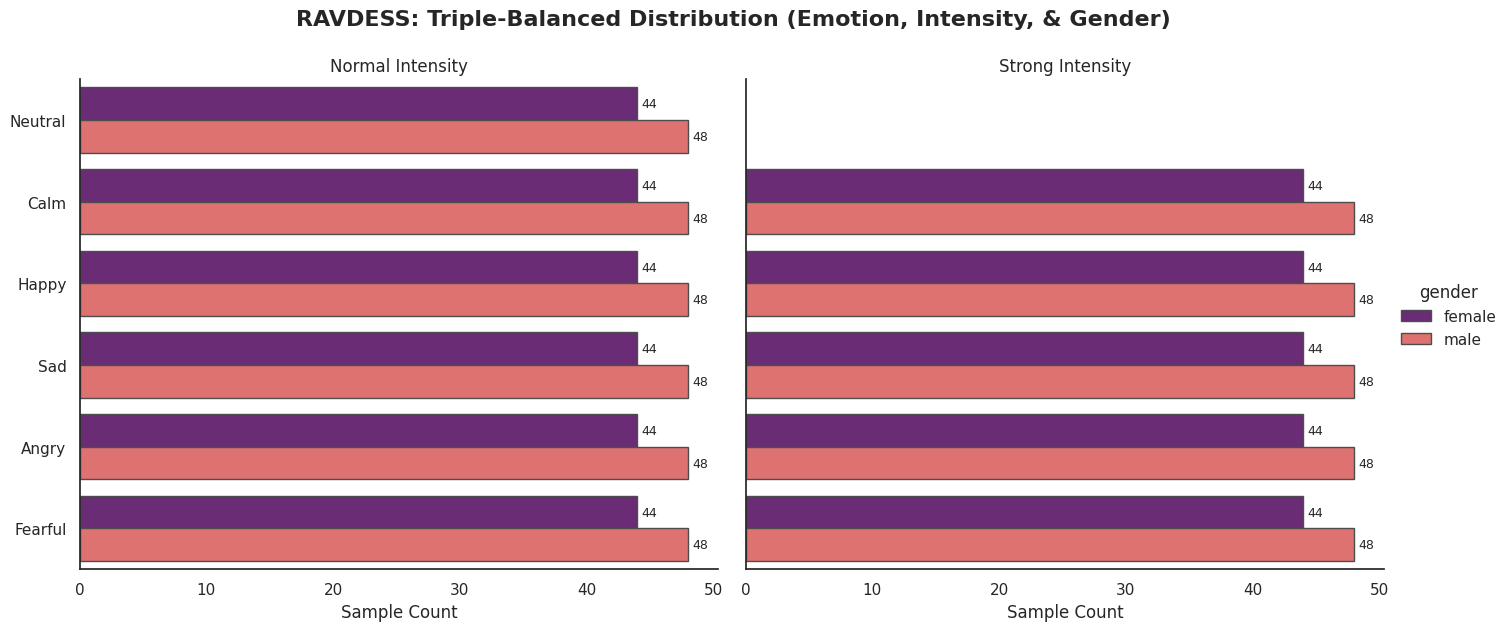

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

emotion_map = {1: 'Neutral', 2: 'Calm', 3: 'Happy', 4: 'Sad', 5: 'Angry', 6: 'Fearful', 7: 'Disgust', 8: 'Surprised'}
intensity_map = {1: 'Normal', 2: 'Strong'}

df_ravdess['emotion_name'] = df_ravdess['emotion'].map(emotion_map)
df_ravdess['intensity_name'] = df_ravdess['intensity'].map(intensity_map)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=df_ravdess,
    y='emotion_name',
    hue='intensity_name',
    palette='viridis',
    edgecolor="0.2"
)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, fontweight='bold')

plt.title('RAVDESS: Κατανομή Συναισθημάτων ανά Ένταση', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Αριθμός Δειγμάτων', fontsize=12)
plt.ylabel('Συναίσθημα', fontsize=12)
plt.legend(title='Ένταση', loc='lower right')

# Αφαίρεση περιττών γραμμών γύρω-γύρω για "clean look"
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## loso

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score
)

def loso_evaluation(df, feature_cols, model, target_col, group_col='actor_id', plot_cm=True):
    """
    Runs a Leave-One-Speaker-Out (LOSO) evaluation
    """

    emotion_labels = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful']

    X = df[feature_cols].values
    y = df[target_col].values
    groups = df[group_col].values

    logo = LeaveOneGroupOut()

    accuracies = []
    balanced_accuracies = []
    y_true_all, y_pred_all = [], []

    print("Starting Leave-One-Speaker-Out Evaluation...\n")

    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Fit & predict
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        bacc = balanced_accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        balanced_accuracies.append(bacc)
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"Speaker {groups[test_idx][0]} accuracy: {acc:.3f}")

    # Overall metrics
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)
    mean_bacc = np.mean(balanced_accuracies)
    std_bacc = np.std(balanced_accuracies)

    overall_balanced_acc = balanced_accuracy_score(y_true_all, y_pred_all)

    print(f"\n Mean LOSO Accuracy: {mean_acc:.3f} and std: {std_acc:.3f}\n")
    print(f"\n Mean LOSO B. Accuracy: {mean_bacc:.3f} and std: {std_bacc:.3f}\n")

    print(f"\n Mean LOSO Global Balanced Accuracy: {overall_balanced_acc:.3f}\n")

    # Classification Report
    print("Overall Classification Report:")
    print(classification_report(y_true_all, y_pred_all, target_names=emotion_labels))

    # Confusion matrix
    cm = confusion_matrix(y_true_all, y_pred_all)

    if plot_cm:
        plt.figure(figsize=(10, 8))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels)
        disp.plot(cmap='Blues', values_format='d', colorbar=False)

        plt.title("LOSO Confusion Matrix")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    return {
        "accuracies": accuracies,
        "mean_acc": mean_acc,
        "std_acc": std_acc,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "confusion_matrix": cm,
        "balanced_accuracy": overall_balanced_acc,
        "mean_bacc": mean_bacc,
        "std_bacc": std_bacc
    }

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier

# Define feature groups
metadata = ['modality', 'vocal_channel', 'emotion', 'intensity',
            'statement', 'repetition', 'gender', 'filename', 'emotion_name',
            'emotion_xgb', 'actor_id']

prosodic = ['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
            'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
            'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
            'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
            'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
            'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',
            'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2',
            'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope',
            'loudness_sma3_stddevFallingSlope', 'loudnessPeaksPerSec', 'VoicedSegmentsPerSec',
            'MeanVoicedSegmentLengthSec', 'StddevVoicedSegmentLengthSec', 'MeanUnvoicedSegmentLength',
            'StddevUnvoicedSegmentLength', 'equivalentSoundLevel_dBp', 'delta_energy_mean',
            'delta_energy_std', 'delta_pitch_std', 'delta_pitch_mean', 'st_loudness_variability', 'lt_loudness_variability',
            'jitterLocal_sma3nz_amean', 'pitch_variability', 'melodic_deviation', 'dett_mean', 'dett_std', 'dett_cv', 'pitch_bias',
            'jitterLocal_sma3nz_stddevNorm', 'shimmerLocaldB_sma3nz_amean', 'shimmerLocaldB_sma3nz_stddevNorm']

spectral = ['spectralFlux_sma3_amean', 'spectralFlux_sma3_stddevNorm',
            'HNRdBACF_sma3nz_amean', 'HNRdBACF_sma3nz_stddevNorm', 'logRelF0-H1-H2_sma3nz_amean',
            'logRelF0-H1-H2_sma3nz_stddevNorm', 'logRelF0-H1-A3_sma3nz_amean', 'logRelF0-H1-A3_sma3nz_stddevNorm',
            'F1frequency_sma3nz_amean', 'F1frequency_sma3nz_stddevNorm', 'F1bandwidth_sma3nz_amean',
            'F1bandwidth_sma3nz_stddevNorm', 'F1amplitudeLogRelF0_sma3nz_amean', 'F1amplitudeLogRelF0_sma3nz_stddevNorm',
            'F2frequency_sma3nz_amean', 'F2frequency_sma3nz_stddevNorm', 'F2bandwidth_sma3nz_amean',
            'F2bandwidth_sma3nz_stddevNorm', 'F2amplitudeLogRelF0_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_stddevNorm',
            'F3frequency_sma3nz_amean', 'F3frequency_sma3nz_stddevNorm', 'F3bandwidth_sma3nz_amean',
            'F3bandwidth_sma3nz_stddevNorm', 'F3amplitudeLogRelF0_sma3nz_amean', 'F3amplitudeLogRelF0_sma3nz_stddevNorm',
            'alphaRatioV_sma3nz_amean', 'alphaRatioV_sma3nz_stddevNorm', 'hammarbergIndexV_sma3nz_amean',
            'hammarbergIndexV_sma3nz_stddevNorm', 'slopeV0-500_sma3nz_amean', 'slopeV0-500_sma3nz_stddevNorm',
            'slopeV500-1500_sma3nz_amean', 'slopeV500-1500_sma3nz_stddevNorm', 'spectralFluxV_sma3nz_amean',
            'spectralFluxV_sma3nz_stddevNorm', 'alphaRatioUV_sma3nz_amean', 'hammarbergIndexUV_sma3nz_amean',
            'slopeUV0-500_sma3nz_amean', 'slopeUV500-1500_sma3nz_amean', 'spectralFluxUV_sma3nz_amean',
            'spectral_flatness_mean', 'spectral_flatness_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'zcr_mean', 'zcr_std',
            ]

phonemes = ['phoneme_duration_cv',
            'articulation_rate',
            'vowel_ratio',
            'consonant_ratio',
            'avg_distance_pauses',
            'mean_pause_dur',
            'std_pause_dur',
            'mean_phoneme_duration',
            'std_phoneme_duration',
            'pause_ratio']

techniques = ['vibrato_mean', 'vibrato_std', 'vibrato_max',
              'vibrato_peak_factor', 'mix_mean', 'mix_std', 'mix_max',
              'mix_peak_factor', 'falsetto_mean', 'falsetto_std', 'falsetto_max',
              'falsetto_peak_factor', 'breathy_mean', 'breathy_std', 'breathy_max',
              'breathy_peak_factor', 'pharyngeal_mean', 'pharyngeal_std',
              'pharyngeal_max', 'pharyngeal_peak_factor', 'glissando_mean',
              'glissando_std', 'glissando_max', 'glissando_peak_factor',
              'num_tech_changes', 'tech_entropy',  'MFDR_slow',
              'MFDR_vibrato', 'MFDR_high',
              'MFDR_slow2vibrato', 'MFDR_vibrato2high']

all_features = prosodic + spectral + phonemes + techniques

In [ ]:
len(all_features)

131

# without singing specific features

In [ ]:
prosodic = ['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
            'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
            'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
            'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
            'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
            'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',
            'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2',
            'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope',
            'loudness_sma3_stddevFallingSlope', 'loudnessPeaksPerSec', 'VoicedSegmentsPerSec',
            'MeanVoicedSegmentLengthSec', 'StddevVoicedSegmentLengthSec', 'MeanUnvoicedSegmentLength',
            'StddevUnvoicedSegmentLength', 'equivalentSoundLevel_dBp',
            'jitterLocal_sma3nz_amean',
            'jitterLocal_sma3nz_stddevNorm', 'shimmerLocaldB_sma3nz_amean', 'shimmerLocaldB_sma3nz_stddevNorm']

spectral = ['spectralFlux_sma3_amean', 'spectralFlux_sma3_stddevNorm',
            'HNRdBACF_sma3nz_amean', 'HNRdBACF_sma3nz_stddevNorm', 'logRelF0-H1-H2_sma3nz_amean',
            'logRelF0-H1-H2_sma3nz_stddevNorm', 'logRelF0-H1-A3_sma3nz_amean', 'logRelF0-H1-A3_sma3nz_stddevNorm',
            'F1frequency_sma3nz_amean', 'F1frequency_sma3nz_stddevNorm', 'F1bandwidth_sma3nz_amean',
            'F1bandwidth_sma3nz_stddevNorm', 'F1amplitudeLogRelF0_sma3nz_amean', 'F1amplitudeLogRelF0_sma3nz_stddevNorm',
            'F2frequency_sma3nz_amean', 'F2frequency_sma3nz_stddevNorm', 'F2bandwidth_sma3nz_amean',
            'F2bandwidth_sma3nz_stddevNorm', 'F2amplitudeLogRelF0_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_stddevNorm',
            'F3frequency_sma3nz_amean', 'F3frequency_sma3nz_stddevNorm', 'F3bandwidth_sma3nz_amean',
            'F3bandwidth_sma3nz_stddevNorm', 'F3amplitudeLogRelF0_sma3nz_amean', 'F3amplitudeLogRelF0_sma3nz_stddevNorm',
            'alphaRatioV_sma3nz_amean', 'alphaRatioV_sma3nz_stddevNorm', 'hammarbergIndexV_sma3nz_amean',
            'hammarbergIndexV_sma3nz_stddevNorm', 'slopeV0-500_sma3nz_amean', 'slopeV0-500_sma3nz_stddevNorm',
            'slopeV500-1500_sma3nz_amean', 'slopeV500-1500_sma3nz_stddevNorm', 'spectralFluxV_sma3nz_amean',
            'spectralFluxV_sma3nz_stddevNorm', 'alphaRatioUV_sma3nz_amean', 'hammarbergIndexUV_sma3nz_amean',
            'slopeUV0-500_sma3nz_amean', 'slopeUV500-1500_sma3nz_amean', 'spectralFluxUV_sma3nz_amean'
            ]

In [ ]:
spectral = ['HNRdBACF_sma3nz_amean', 'alphaRatioV_sma3nz_stddevNorm', #'spectralFluxV_sma3nz_amean',
            'F2amplitudeLogRelF0_sma3nz_stddevNorm', 'alphaRatioV_sma3nz_amean', 'spectralFluxUV_sma3nz_amean', 'F1bandwidth_sma3nz_stddevNorm',
            'logRelF0-H1-A3_sma3nz_amean', 'slopeV0-500_sma3nz_amean', 'F2frequency_sma3nz_stddevNorm']

phoneme = ['articulation_rate', 'std_phoneme_duration']

prosodic = ['loudness_sma3_percentile80.0', 'loudnessPeaksPerSec',
            'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'shimmerLocaldB_sma3nz_amean',
            'shimmerLocaldB_sma3nz_stddevNorm', 'MeanVoicedSegmentLengthSec']

speech = prosodic + spectral + phoneme

In [ ]:
len(speech)

19

In [ ]:
# 1. Calculate correlation for all selected features
corr_matrix = df_ravdess[speech].corr().abs()

# 2. Filter to keep only the upper triangle (to avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Identify pairs with high correlation
high_corr_threshold = 0.9
to_drop = []
pairs = []

for column in upper.columns:
    for row in upper.index:
        if upper.loc[row, column] > high_corr_threshold:
            pairs.append({
                'Feature 1': row,
                'Feature 2': column,
                'Correlation': upper.loc[row, column]
            })
            # Add to the drop list (the second feature of the pair)
            if column not in to_drop:
                to_drop.append(column)

# Check if any pairs were found
if pairs:
    high_corr_df = pd.DataFrame(pairs).sort_values(by='Correlation', ascending=False)
    print(f"Found {len(high_corr_df)} pairs with correlation > {high_corr_threshold}")
    print(high_corr_df.head(20))
else:
    print(f"No feature pairs found with a correlation above {high_corr_threshold}.")

No feature pairs found with a correlation above 0.9.


Starting Leave-One-Speaker-Out Evaluation...

Speaker 1 accuracy: 0.818
Speaker 2 accuracy: 0.909
Speaker 3 accuracy: 0.750
Speaker 4 accuracy: 0.886
Speaker 5 accuracy: 0.750
Speaker 6 accuracy: 0.818
Speaker 7 accuracy: 0.841
Speaker 8 accuracy: 0.773
Speaker 9 accuracy: 0.591
Speaker 10 accuracy: 0.795
Speaker 11 accuracy: 0.909
Speaker 12 accuracy: 0.682
Speaker 13 accuracy: 0.750
Speaker 14 accuracy: 0.864
Speaker 15 accuracy: 0.841
Speaker 16 accuracy: 0.818
Speaker 17 accuracy: 0.727
Speaker 19 accuracy: 0.545
Speaker 20 accuracy: 0.591
Speaker 21 accuracy: 0.955
Speaker 22 accuracy: 0.727
Speaker 23 accuracy: 0.750
Speaker 24 accuracy: 0.909

 Mean LOSO Accuracy: 0.783 and std: 0.106


 Mean LOSO B. Accuracy: 0.789 and std: 0.102


 Mean LOSO Global Balanced Accuracy: 0.789

Overall Classification Report:
              precision    recall  f1-score   support

     Neutral       0.88      0.86      0.87        92
        Calm       0.82      0.79      0.80       184
       Happy

<Figure size 1000x800 with 0 Axes>

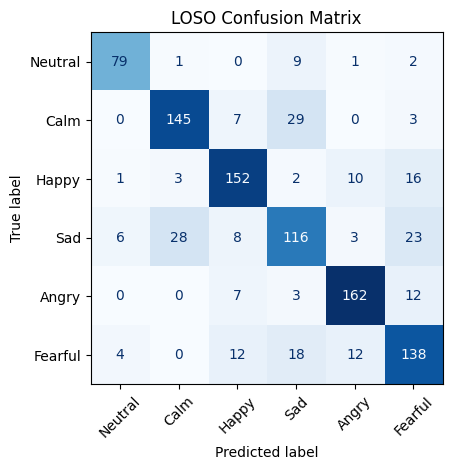

In [ ]:
import xgboost as xgb

import matplotlib.pyplot as plt

# XGBoost expects 0 to N-1 labels

df_ravdess['emotion_xgb'] = df_ravdess['emotion'] - 1


xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    subsample=0.8,
    learning_rate=0.1,
    objective='multi:softprob',
    random_state=42,
    colsample_bytree=0.8
)

# loso evaluation

results_full = loso_evaluation(
    df_ravdess,
    feature_cols=speech,
    model=xgb_model,
    target_col='emotion_xgb'
)

# normal

Starting Leave-One-Speaker-Out Evaluation...

Speaker 1 accuracy: 0.886
Speaker 2 accuracy: 0.977
Speaker 3 accuracy: 0.864
Speaker 4 accuracy: 0.818
Speaker 5 accuracy: 0.727
Speaker 6 accuracy: 0.886
Speaker 7 accuracy: 0.818
Speaker 8 accuracy: 0.795
Speaker 9 accuracy: 0.727
Speaker 10 accuracy: 0.750
Speaker 11 accuracy: 0.909
Speaker 12 accuracy: 0.659
Speaker 13 accuracy: 0.795
Speaker 14 accuracy: 0.886
Speaker 15 accuracy: 0.841
Speaker 16 accuracy: 0.886
Speaker 17 accuracy: 0.795
Speaker 19 accuracy: 0.682
Speaker 20 accuracy: 0.614
Speaker 21 accuracy: 0.932
Speaker 22 accuracy: 0.795
Speaker 23 accuracy: 0.841
Speaker 24 accuracy: 0.909

 Mean LOSO Accuracy: 0.817 and std: 0.090


 Mean LOSO B. Accuracy: 0.823 and std: 0.086


 Mean LOSO Global Balanced Accuracy: 0.823

Overall Classification Report:
              precision    recall  f1-score   support

     Neutral       0.96      0.89      0.93        92
        Calm       0.91      0.84      0.87       184
       Happy

<Figure size 1000x800 with 0 Axes>

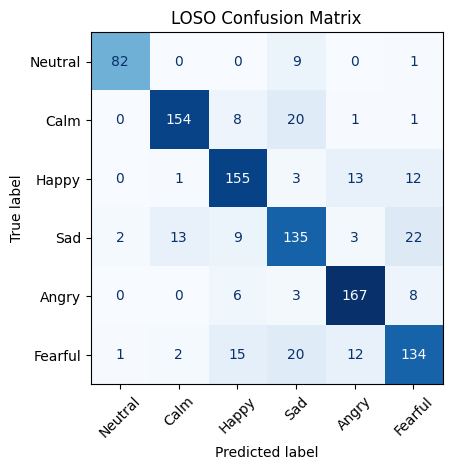

In [ ]:
import xgboost as xgb

import matplotlib.pyplot as plt

# XGBoost expects 0 to N-1 labels

df_ravdess['emotion_xgb'] = df_ravdess['emotion'] - 1

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    subsample=0.8,
    learning_rate=0.1,
    objective='multi:softprob',
    random_state=42,
    colsample_bytree=0.8
)

# loso evaluation
results_full = loso_evaluation(
    df_ravdess,
    feature_cols=all_features,
    model=xgb_model,
    target_col='emotion_xgb'
)

# NESTED LOSO - feature selection

In [ ]:
from collections import Counter
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import xgboost as xgb
import pandas as pd
import numpy as np

def get_nested_loso_top_features(df, group_features, target_col, group_col='actor_id', top_n=10):
    """
    Nested LOSO feature selection using XGBoost.

    Returns:
        all_fold_preds: list of predicted labels for each outer test speaker
        all_fold_actuals: corresponding true labels
        fold_feature_sets: list of selected features per outer fold
    """
    le = LabelEncoder()
    y = le.fit_transform(df[target_col])
    X = df[group_features]
    groups = df[group_col]

    logo_outer = LeaveOneGroupOut()
    fold_feature_sets = []
    all_fold_preds = []
    all_fold_actuals = []

    print(f"Analyzing {len(group_features)} features over {groups.nunique()} speakers...")

    # OUTER LOOP: LOSO per speaker
    for fold_idx, (train_idx, test_idx) in enumerate(logo_outer.split(X, y, groups), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        train_groups = groups.iloc[train_idx]
        test_groups = groups.iloc[test_idx]
        test_speaker = np.unique(test_groups)[0]

        print(f"\n Fold {fold_idx} | Test speaker: {test_speaker}")

        # INNER FEATURE SELECTION (train speakers only)
        feature_counter = Counter()
        logo_inner = LeaveOneGroupOut()
        inner_train_indices = train_idx

        for inner_train_idx, inner_val_idx in logo_inner.split(X_train, y_train, train_groups):
            X_inner_train, y_inner_train = X_train.iloc[inner_train_idx], y_train[inner_train_idx]

            model_inner = xgb.XGBClassifier(
                n_estimators=100,
                max_depth=4,
                learning_rate=0.1,
                random_state=42,
                eval_metric='mlogloss'
            )
            model_inner.fit(X_inner_train, y_inner_train)

            # Feature importances
            importance = pd.Series(model_inner.feature_importances_, index=group_features)
            top_features = importance.nlargest(top_n).index.tolist()
            feature_counter.update(top_features)

        # Final selected features for this outer fold
        selected_features = [f for f, _ in feature_counter.most_common(top_n)]
        fold_feature_sets.append(selected_features)
        selected_indices = [group_features.index(f) for f in selected_features]

        print(f"   → Selected {len(selected_features)} features: {selected_features}")

        # TRAIN FINAL MODEL WITH SELECTED FEATURES
        X_train_sel = X_train.iloc[:, selected_indices]
        X_test_sel = X_test.iloc[:, selected_indices]

        final_model = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.1,
            random_state=42,
            eval_metric='mlogloss'
        )
        final_model.fit(X_train_sel, y_train)

        # TEST
        y_pred = final_model.predict(X_test_sel)
        all_fold_preds.extend(y_pred)
        all_fold_actuals.extend(y_test)

    # FINAL METRICS
    mean_acc = accuracy_score(all_fold_actuals, all_fold_preds)
    print(f"\nNested LOSO Mean Accuracy: {mean_acc:.3f}")

    return all_fold_preds, all_fold_actuals, fold_feature_sets


In [ ]:
result_prosodic = get_nested_loso_top_features(df_ravdess, prosodic, 'emotion', 'actor_id', 10)

Analyzing 43 features over 23 speakers...

🔹 Fold 1 | Test speaker: 1
   → Selected 10 features: ['F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2', 'shimmerLocaldB_sma3nz_amean', 'loudness_sma3_meanRisingSlope', 'loudnessPeaksPerSec', 'melodic_deviation', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'loudness_sma3_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_amean']

🔹 Fold 2 | Test speaker: 2
   → Selected 10 features: ['F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'loudness_sma3_percentile80.0', 'shimmerLocaldB_sma3nz_amean', 'loudness_sma3_meanRisingSlope', 'loudnessPeaksPerSec', 'melodic_deviation', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_amean', 'loudness_sma3_pctlrange0-2', 'loudness_sma3_meanFallingSlope']

🔹 Fold 3 | Test speaker: 3
   → Selected 10 features: ['shimmerLocaldB_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'loudness_sma3_meanRisingSlope', 'loudness_sma3_percentile8

KeyboardInterrupt: 

In [ ]:
result_spectral = get_nested_loso_top_features(df_ravdess, spectral, 'emotion', 'actor_id', 10)

Analyzing 47 features over 23 speakers...

🔹 Fold 1 | Test speaker: 1
   → Selected 10 features: ['HNRdBACF_sma3nz_amean', 'alphaRatioV_sma3nz_stddevNorm', 'spectralFluxV_sma3nz_amean', 'F3amplitudeLogRelF0_sma3nz_stddevNorm', 'F2amplitudeLogRelF0_sma3nz_stddevNorm', 'alphaRatioV_sma3nz_amean', 'spectralFlux_sma3_amean', 'spectralFluxUV_sma3nz_amean', 'spectralFluxV_sma3nz_stddevNorm', 'logRelF0-H1-A3_sma3nz_amean']

🔹 Fold 2 | Test speaker: 2
   → Selected 10 features: ['HNRdBACF_sma3nz_amean', 'alphaRatioV_sma3nz_stddevNorm', 'spectralFluxV_sma3nz_amean', 'F3amplitudeLogRelF0_sma3nz_stddevNorm', 'F2amplitudeLogRelF0_sma3nz_stddevNorm', 'alphaRatioV_sma3nz_amean', 'spectralFlux_sma3_amean', 'spectralFluxUV_sma3nz_amean', 'logRelF0-H1-A3_sma3nz_amean', 'F2frequency_sma3nz_stddevNorm']

🔹 Fold 3 | Test speaker: 3


KeyboardInterrupt: 

In [ ]:
result_tech = get_nested_loso_top_features(df_ravdess, techniques, 'emotion', 'actor_id', 10)

Analyzing 31 features over 23 speakers...

🔹 Fold 1 | Test speaker: 1
   → Selected 10 features: ['pharyngeal_max', 'falsetto_max', 'pharyngeal_mean', 'glissando_max', 'breathy_max', 'MFDR_vibrato', 'breathy_mean', 'vibrato_mean', 'MFDR_high', 'pharyngeal_peak_factor']

🔹 Fold 2 | Test speaker: 2
   → Selected 10 features: ['pharyngeal_max', 'falsetto_max', 'pharyngeal_mean', 'glissando_max', 'breathy_max', 'MFDR_vibrato', 'breathy_mean', 'pharyngeal_peak_factor', 'vibrato_mean', 'MFDR_high']

🔹 Fold 3 | Test speaker: 3
   → Selected 10 features: ['pharyngeal_max', 'falsetto_max', 'pharyngeal_mean', 'glissando_max', 'breathy_mean', 'MFDR_vibrato', 'breathy_max', 'MFDR_high', 'pharyngeal_peak_factor', 'vibrato_mean']

🔹 Fold 4 | Test speaker: 4
   → Selected 10 features: ['pharyngeal_max', 'pharyngeal_mean', 'falsetto_max', 'glissando_max', 'breathy_max', 'MFDR_vibrato', 'pharyngeal_peak_factor', 'breathy_mean', 'MFDR_high', 'vibrato_mean']

🔹 Fold 5 | Test speaker: 5


KeyboardInterrupt: 

In [ ]:
result_phon = get_nested_loso_top_features(df_ravdess, phonemes, 'emotion', 'actor_id', 10)

Analyzing 10 features over 23 speakers...

🔹 Fold 1 | Test speaker: 1
   → Selected 10 features: ['articulation_rate', 'mean_phoneme_duration', 'vowel_ratio', 'phoneme_duration_cv', 'consonant_ratio', 'pause_ratio', 'std_phoneme_duration', 'std_pause_dur', 'mean_pause_dur', 'avg_distance_pauses']

🔹 Fold 2 | Test speaker: 2
   → Selected 10 features: ['articulation_rate', 'mean_phoneme_duration', 'vowel_ratio', 'phoneme_duration_cv', 'consonant_ratio', 'pause_ratio', 'std_phoneme_duration', 'std_pause_dur', 'mean_pause_dur', 'avg_distance_pauses']

🔹 Fold 3 | Test speaker: 3


KeyboardInterrupt: 

In [ ]:
best_prosodic = [
    'shimmerLocaldB_sma3nz_amean',
    'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
    'loudnessPeaksPerSec', 'melodic_deviation'
]
best_spectral = [
    'HNRdBACF_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_stddevNorm', 'alphaRatioV_sma3nz_stddevNorm',
    'spectralFlux_sma3_amean', 'alphaRatioV_sma3nz_amean'
]
best_phonemes = ['articulation_rate', 'std_phoneme_duration']

best_techniques = ['MFDR_vibrato', 'breathy_mean', 'pharyngeal_max',
    'falsetto_max', 'glissando_max', 'tech_entropy'
]

all_feats = best_prosodic + best_spectral + best_phonemes + best_techniques
print(len(best_prosodic), len(best_spectral), len(best_phonemes), len(best_techniques))
print(len(all_feats))


5 5 2 6
18


In [ ]:
import numpy as np
# 1. Calculate correlation for all selected features
corr_matrix = df_ravdess[all_feats].corr().abs()

# 2. Filter to keep only the upper triangle (to avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Identify pairs with high correlation
high_corr_threshold = 0.9
to_drop = []
pairs = []

for column in upper.columns:
    for row in upper.index:
        if upper.loc[row, column] > high_corr_threshold:
            pairs.append({
                'Feature 1': row,
                'Feature 2': column,
                'Correlation': upper.loc[row, column]
            })
            # Add to the drop list (the second feature of the pair)
            if column not in to_drop:
                to_drop.append(column)

# Check if any pairs were found
if pairs:
    high_corr_df = pd.DataFrame(pairs).sort_values(by='Correlation', ascending=False)
    print(f"Found {len(high_corr_df)} pairs with correlation > {high_corr_threshold}")
    print(high_corr_df.head(20))
else:
    print(f"No feature pairs found with a correlation above {high_corr_threshold}.")

No feature pairs found with a correlation above 0.9.


# with mfdr-vibrato

Starting Leave-One-Speaker-Out Evaluation...

Speaker 1 accuracy: 0.795
Speaker 2 accuracy: 0.886
Speaker 3 accuracy: 0.795
Speaker 4 accuracy: 0.773
Speaker 5 accuracy: 0.773
Speaker 6 accuracy: 0.818
Speaker 7 accuracy: 0.750
Speaker 8 accuracy: 0.750
Speaker 9 accuracy: 0.750
Speaker 10 accuracy: 0.864
Speaker 11 accuracy: 0.818
Speaker 12 accuracy: 0.705
Speaker 13 accuracy: 0.773
Speaker 14 accuracy: 0.864
Speaker 15 accuracy: 0.795
Speaker 16 accuracy: 0.818
Speaker 17 accuracy: 0.727
Speaker 19 accuracy: 0.591
Speaker 20 accuracy: 0.705
Speaker 21 accuracy: 0.864
Speaker 22 accuracy: 0.773
Speaker 23 accuracy: 0.773
Speaker 24 accuracy: 0.955

 Mean LOSO Accuracy: 0.788 and std: 0.072


 Mean LOSO B. Accuracy: 0.793 and std: 0.074


 Mean LOSO Global Balanced Accuracy: 0.793

Overall Classification Report:
              precision    recall  f1-score   support

     Neutral       0.92      0.86      0.89        92
        Calm       0.89      0.85      0.87       184
       Happy

<Figure size 1000x800 with 0 Axes>

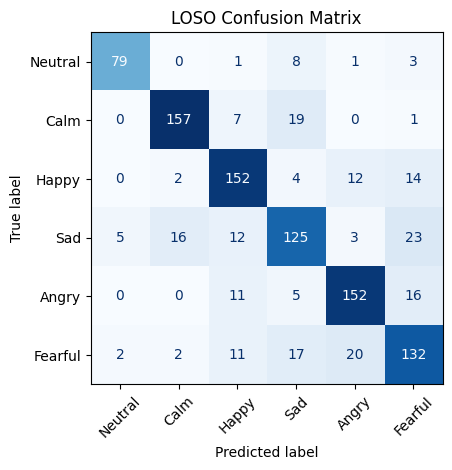

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

df_ravdess['emotion_xgb'] = df_ravdess['emotion'] - 1

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    subsample=0.8,
    learning_rate=0.1,
    objective='multi:softprob',
    random_state=42,
    colsample_bytree=0.8
)


results_sel = loso_evaluation(
    df_ravdess,
    feature_cols=all_feats,
    model=xgb_model,
    target_col='emotion_xgb'
)

# lime test

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=faeee2fa17bec80500ae05f622e7f45a24f099a535dc20bcdfdd42abc19b6bd0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular

# 1. Διαχωρισμός: Training = Όλοι οι άλλοι, Test = Μόνο ο Speaker 20
train_data = df_ravdess[df_ravdess['actor_id'] != 20]
test_data = df_ravdess[df_ravdess['actor_id'] == 20]

X_train = train_data[all_feats]
y_train = train_data['emotion_xgb']

X_test = test_data[all_feats]
y_test = test_data['emotion_xgb']

# 2. Εκπαίδευση του μοντέλου (όπως ακριβώς γίνεται μέσα στο LOSO loop)
xgb_model.fit(X_train, y_train)

# 3. Δημιουργία του LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=all_feats,
    class_names=['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful'], # Με τη σωστή σειρά
    mode='classification'
)

In [ ]:
import lime
import lime.lime_tabular

# 1. Διαχωρισμός: Training = Όλοι οι άλλοι, Test = Μόνο ο Speaker 20
train_data = df_ravdess[df_ravdess['actor_id'] != 20]
test_data = df_ravdess[df_ravdess['actor_id'] == 20]

X_train = train_data[all_feats]
y_train = train_data['emotion_xgb']

X_test = test_data[all_feats]
y_test = test_data['emotion_xgb']

# 2. Εκπαίδευση του μοντέλου (όπως ακριβώς γίνεται μέσα στο LOSO loop)
xgb_model.fit(X_train, y_train)

# 3. Δημιουργία του LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=all_feats,
    class_names=['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful'], # Με τη σωστή σειρά
    mode='classification'
)
# Πρόβλεψη για τον Speaker 20
y_pred_20 = xgb_model.predict(X_test)

# Βρίσκουμε τα index των λαθών
errors_idx = np.where(y_pred_20 != y_test.values)[0]

if len(errors_idx) > 0:
    # Παίρνουμε το πρώτο λάθος
    i = errors_idx[0]

    print(f"Actual Label: {y_test.values[i]}")
    print(f"Predicted Label: {y_pred_20[i]}")

    # Εξήγηση με LIME
    exp = explainer.explain_instance(
        X_test.values[i],
        xgb_model.predict_proba,
        num_features=len(all_feats)
    )

    exp.show_in_notebook()

Actual Label: 3
Predicted Label: 2


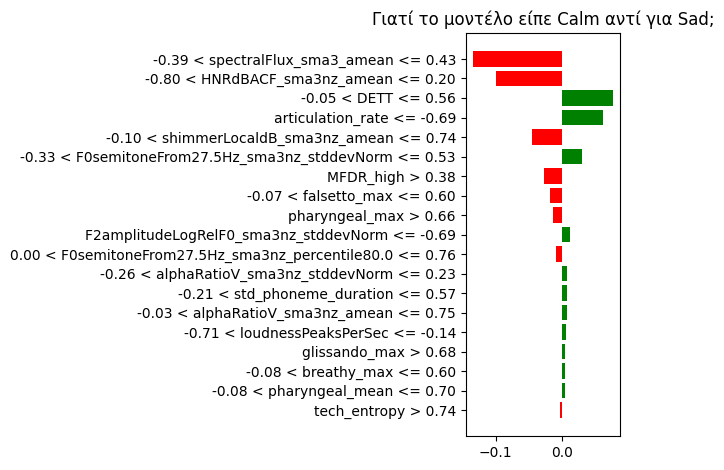

In [ ]:
# Οπτικοποίηση των 10 πιο σημαντικών features για τη συγκεκριμένη πρόβλεψη
fig = exp.as_pyplot_figure()
plt.title("Γιατί το μοντέλο είπε Calm αντί για Sad;")
plt.tight_layout()
plt.show()

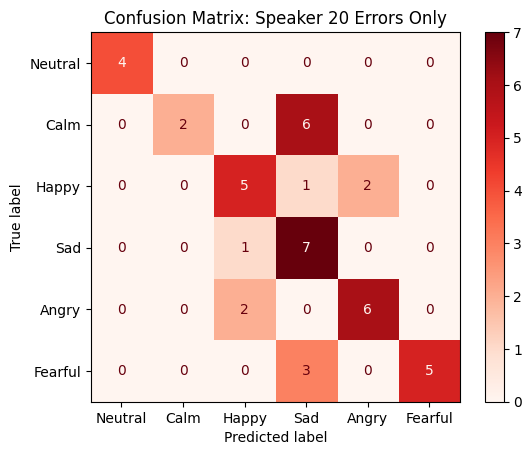

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Προβλέψεις για όλο το X_test (που είναι ο Speaker 20)
y_pred_20 = xgb_model.predict(X_test)

# Υπολογισμός Confusion Matrix
cm_20 = confusion_matrix(y_test, y_pred_20)

# Οπτικοποίηση
disp = ConfusionMatrixDisplay(confusion_matrix=cm_20, display_labels=['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful'])
disp.plot(cmap='Reds')
plt.title("Confusion Matrix: Speaker 20 Errors Only")
plt.show()

# Ablation study

In [ ]:
import pandas as pd
import xgboost as xgb

df_ravdess['emotion_xgb'] = df_ravdess['emotion'] - 1

# dictionary for ablation loop
categories = {
    'Prosodic': best_prosodic,
    'Spectral': best_spectral,
    'Phonemes': best_phonemes,
    'Techniques': best_techniques
}

all_selected_features = [f for sublist in categories.values() for f in sublist]
ablation_records = []

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    subsample=0.8,
    learning_rate=0.1,
    objective='multi:softprob',
    random_state=42,
    colsample_bytree=0.8
)

# --- Scenario 1: Each category ALONE (Only One) ---
print("Running 'Only One' Ablation...")
for name, feats in categories.items():
    res = loso_evaluation(df_ravdess, feats, xgb_model, 'emotion_xgb', plot_cm=False)
    ablation_records.append({
        'Type': 'Single Category',
        'Experiment': f'Only {name}',
        'Accuracy': res['mean_bacc'],
        'Std': res['std_bacc'],
        'Balanced Accuracy': res['balanced_accuracy']
    })

# --- Scenario 2: All categories EXCEPT for one (Leave-One-Out) ---
print("\n Running 'Leave-One-Out' Ablation...")
for name, feats in categories.items():
    current_feats = [f for f in all_selected_features if f not in feats]
    res = loso_evaluation(df_ravdess, current_feats, xgb_model, 'emotion_xgb', plot_cm=False)
    ablation_records.append({
        'Type': 'Leave-One-Out',
        'Experiment': f'All except {name}',
        'Accuracy': res['mean_bacc'],
        'Std': res['std_bacc'],
        'Balanced Accuracy': res['balanced_accuracy']
    })

# --- Baseline: All features ---
print("\n Running Full Model...")
res_full = loso_evaluation(df_ravdess, all_selected_features, xgb_model, 'emotion_xgb', plot_cm=False)
ablation_records.append({
    'Type': 'Full Baseline',
    'Experiment': 'Full Model (All Features)',
    'Accuracy': res_full['mean_bacc'],
    'Std': res_full['std_bacc'],
    'Balanced Accuracy': res['balanced_accuracy']
})

print("\n Running Speech Model...")
res_full = loso_evaluation(df_ravdess, speech, xgb_model, 'emotion_xgb', plot_cm=False)
ablation_records.append({
    'Type': 'Speech-only',
    'Experiment': 'Speech-only',
    'Accuracy': res_full['mean_bacc'],
    'Std': res_full['std_bacc'],
    'Balanced Accuracy': res['balanced_accuracy']
})

print("\n Running 100+ features Model...")
res_full = loso_evaluation(df_ravdess, all_features, xgb_model, 'emotion_xgb', plot_cm=False)
ablation_records.append({
    'Type': 'All',
    'Experiment': 'All_features',
    'Accuracy': res_full['mean_bacc'],
    'Std': res_full['std_bacc'],
    'Balanced Accuracy': res['balanced_accuracy']
})

df_ablation = pd.DataFrame(ablation_records)
print("\nFINAL ABLATION RESULTS")
display(df_ablation.sort_values(by=['Type', 'Accuracy'], ascending=False))

Running 'Only One' Ablation...
Starting Leave-One-Speaker-Out Evaluation...

Speaker 1 accuracy: 0.568
Speaker 2 accuracy: 0.705
Speaker 3 accuracy: 0.568
Speaker 4 accuracy: 0.773
Speaker 5 accuracy: 0.682
Speaker 6 accuracy: 0.705
Speaker 7 accuracy: 0.659
Speaker 8 accuracy: 0.591
Speaker 9 accuracy: 0.568
Speaker 10 accuracy: 0.682
Speaker 11 accuracy: 0.682
Speaker 12 accuracy: 0.750
Speaker 13 accuracy: 0.727
Speaker 14 accuracy: 0.614
Speaker 15 accuracy: 0.659
Speaker 16 accuracy: 0.636
Speaker 17 accuracy: 0.682
Speaker 19 accuracy: 0.432
Speaker 20 accuracy: 0.545
Speaker 21 accuracy: 0.705
Speaker 22 accuracy: 0.591
Speaker 23 accuracy: 0.455
Speaker 24 accuracy: 0.841

 Mean LOSO Accuracy: 0.644 and std: 0.094


 Mean LOSO B. Accuracy: 0.659 and std: 0.099


 Mean LOSO Global Balanced Accuracy: 0.659

Overall Classification Report:
              precision    recall  f1-score   support

     Neutral       0.86      0.83      0.84        92
        Calm       0.79      0.78  

,Type,Experiment,Accuracy,Std,Balanced Accuracy
9,Speech-only,Speech-only,0.788949,0.101748,0.790761
0,Single Category,Only Prosodic,0.659420,0.098603,0.659420
1,Single Category,Only Spectral,0.528080,0.122654,0.528080
3,Single Category,Only Techniques,0.345109,0.101845,0.345109
2,Single Category,Only Phonemes,0.333333,0.100759,0.333333
7,Leave-One-Out,All except Techniques,0.790761,0.072032,0.790761
6,Leave-One-Out,All except Phonemes,0.772645,0.067553,0.772645
5,Leave-One-Out,All except Spectral,0.730072,0.107550,0.730072
4,Leave-One-Out,All except Prosodic,0.633152,0.087258,0.633152
8,Full Baseline,Full Model (All Features),0.793478,0.073954,0.790761


# train full_model

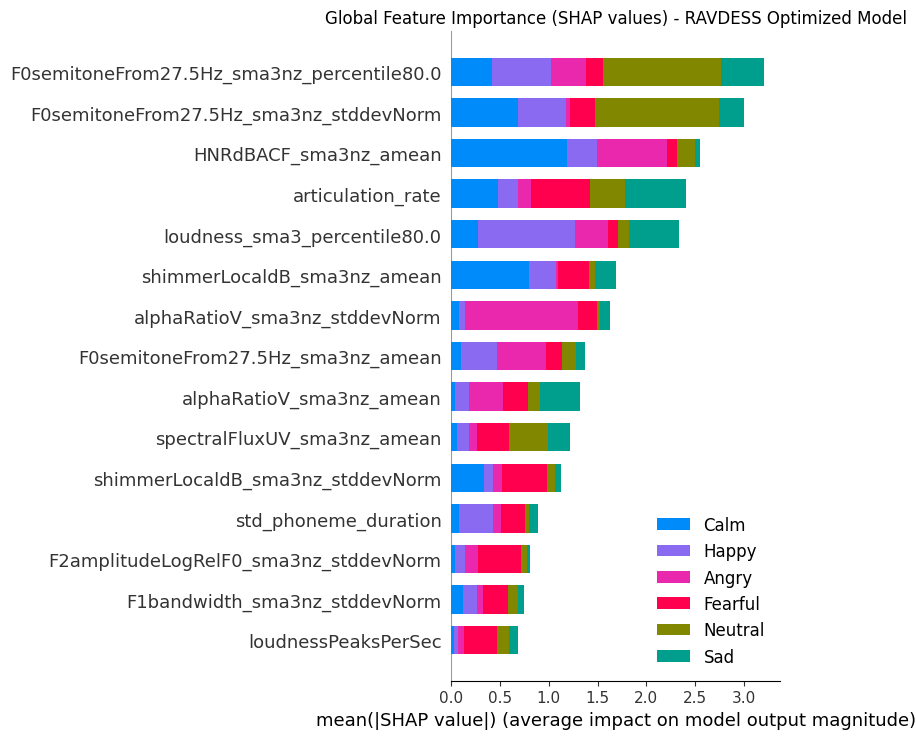

In [ ]:
import shap
import matplotlib.pyplot as plt


final_xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    subsample=0.8,
    learning_rate=0.1,
    objective='multi:softprob',
    random_state=42,
    colsample_bytree=0.8
)


X_final = df_ravdess[speech].values
y_final = df_ravdess['emotion_xgb'].values

# 1. Fit final model
final_xgb_model.fit(df_ravdess[speech], y_final)

# 2. Compute SHAP values
explainer = shap.TreeExplainer(final_xgb_model)
shap_values = explainer.shap_values(df_ravdess[speech])

# 3. Shap summary plot
plt.figure(figsize=(12, 8))
emotion_names = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful']

shap.summary_plot(
    shap_values,
    df_ravdess[speech],
    plot_type="bar",
    class_names=emotion_names,
    max_display=15, # show the 15 most important feats
    show=False
)

plt.title("Global Feature Importance (SHAP values) - RAVDESS Optimized Model")
plt.tight_layout()
plt.show()

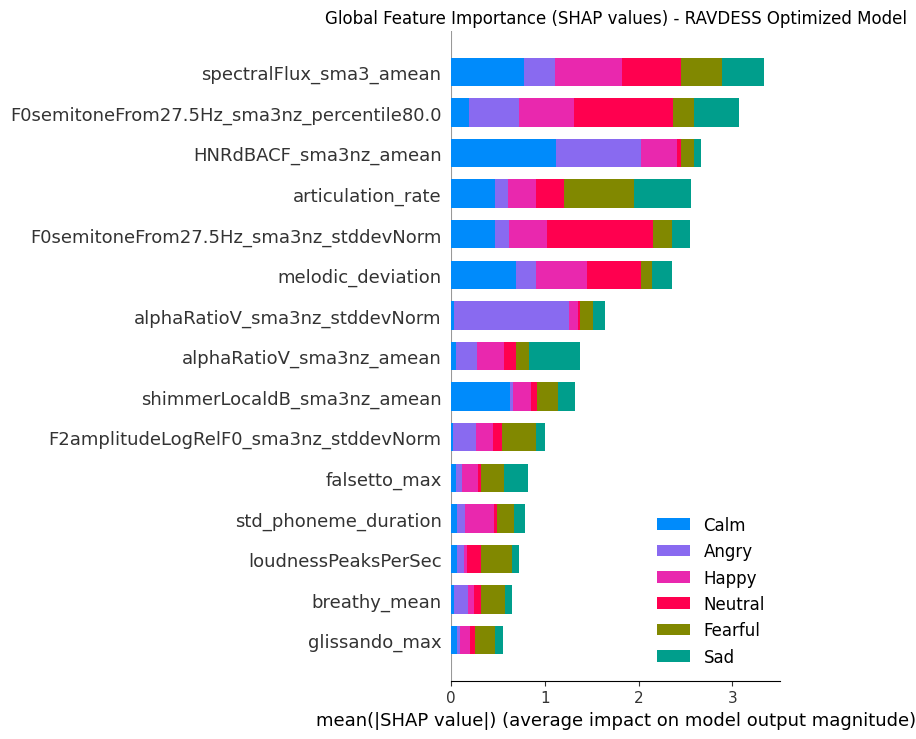

In [ ]:
import shap
import matplotlib.pyplot as plt
import xgboost as xgb

df_ravdess['emotion_xgb'] = df_ravdess['emotion'] - 1

final_xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    subsample=0.8,
    learning_rate=0.1,
    objective='multi:softprob',
    random_state=42,
    colsample_bytree=0.8
)

X_final = df_ravdess[all_feats].values
y_final = df_ravdess['emotion_xgb'].values

# 1. Fit final model
final_xgb_model.fit(df_ravdess[all_feats], y_final)

# 2. Compute SHAP values
explainer = shap.TreeExplainer(final_xgb_model)
shap_values = explainer.shap_values(df_ravdess[all_feats])

# 3. Shap summary plot
plt.figure(figsize=(12, 8))
emotion_names = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful']

shap.summary_plot(
    shap_values,
    df_ravdess[all_feats],
    plot_type="bar",
    class_names=emotion_names,
    max_display=15, # show the 15 most important feats
    show=False
)

plt.title("Global Feature Importance (SHAP values) - RAVDESS Optimized Model")
plt.tight_layout()
plt.show()

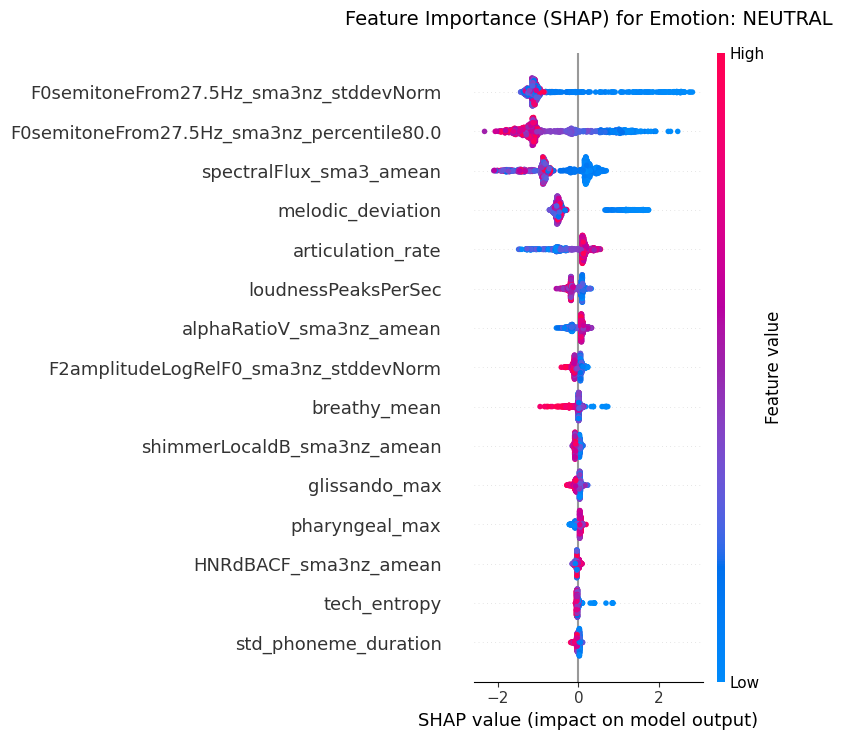

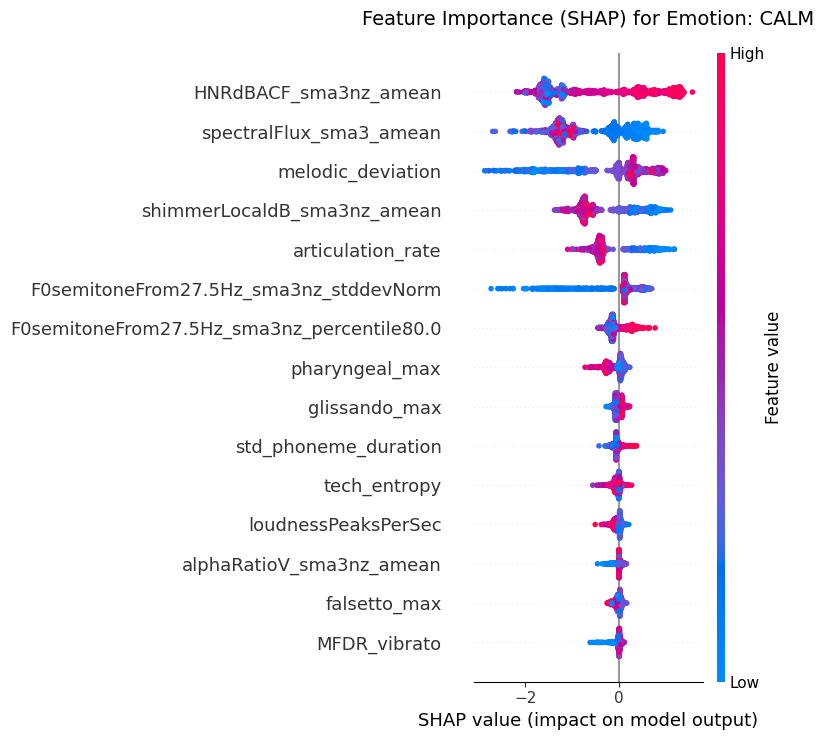

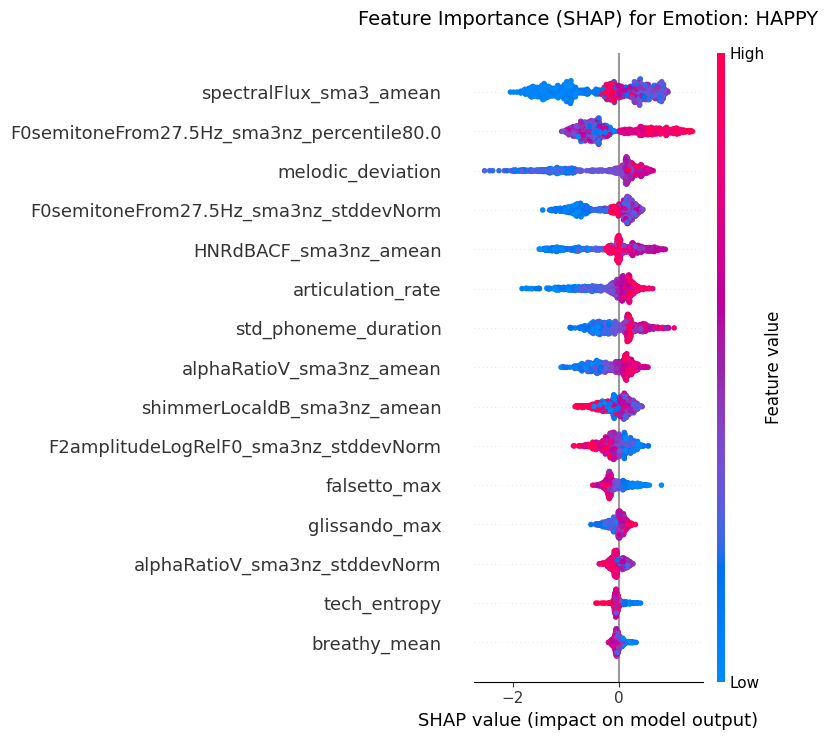

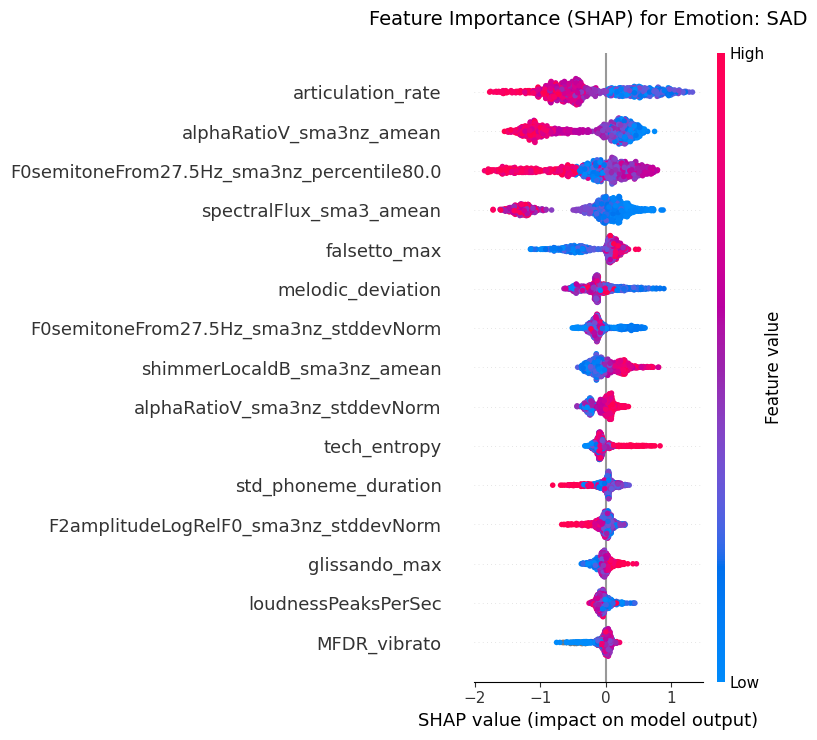

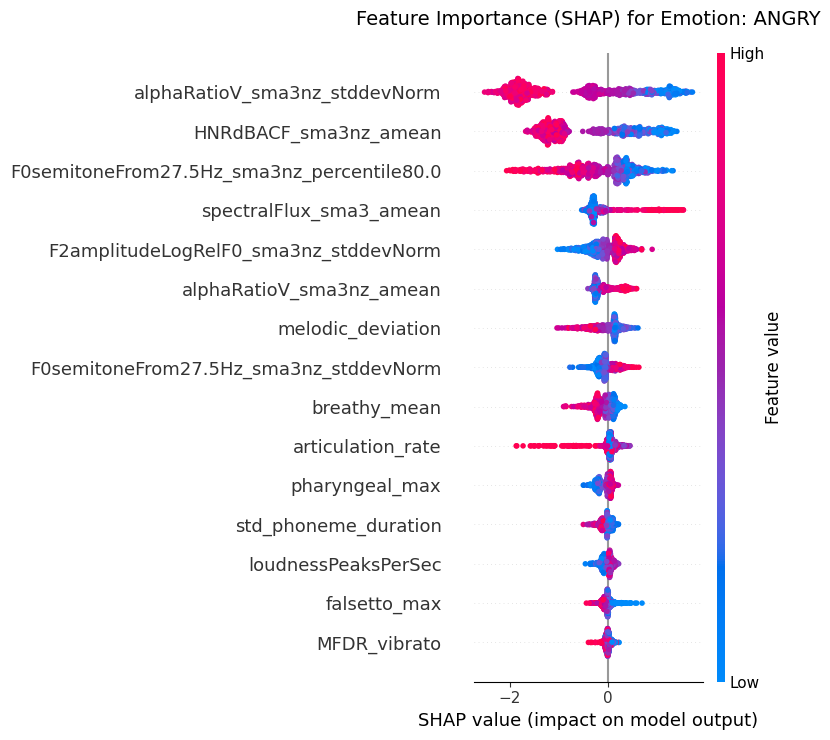

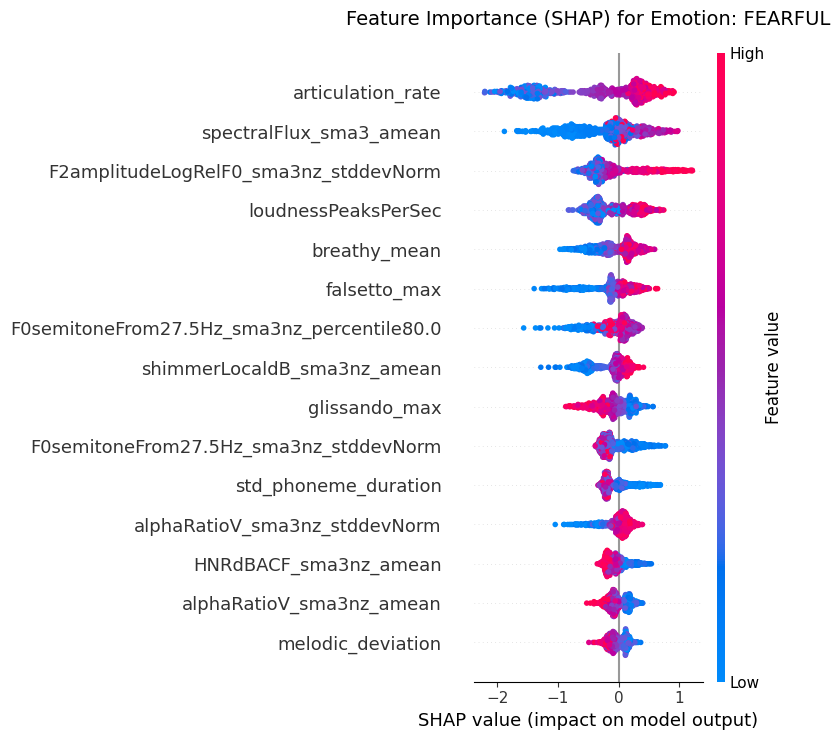

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

X_final_df = df_ravdess[all_feats]

explainer = shap.TreeExplainer(final_xgb_model)
shap_values = explainer.shap_values(X_final_df)

emotion_names = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful']

# Loop to create a summary plot for each emotion
for i, name in enumerate(emotion_names):
    plt.figure(figsize=(10, 6))

    if isinstance(shap_values, list):
        current_shap_values = shap_values[i]
    else:
        current_shap_values = shap_values[:, :, i]

    plt.title(f"Feature Importance (SHAP) for Emotion: {name.upper()}", fontsize=14, pad=20)

    shap.summary_plot(
        current_shap_values,
        X_final_df,
        feature_names=all_feats,
        max_display=15,
        plot_type="dot",   # Dot plot to visualize the impact of feature values (high/low)
        show=False
    )

    plt.tight_layout()
    plt.show()

In [ ]:
import joblib
emotion_names = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful']

production_package = {
    'model': final_xgb_model,
    'feature_names': all_feats,
    'class_names': emotion_names,
    'normalization_type': 'Speaker-Dependent'
}

save_path = '/content/drive/MyDrive/ravdess_vocal_final_modelv6.pkl'
joblib.dump(production_package, save_path)

print(f"Model saved succesfully at: {save_path}")

Model saved succesfully at: /content/drive/MyDrive/ravdess_vocal_final_modelv6.pkl


In [ ]:
import joblib
emotion_names = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful']

production_package = {
    'model': final_xgb_model,
    'feature_names': all_feats,
    'class_names': emotion_names,
    'normalization_type': 'Speaker-Dependent'
}

save_path = '/content/drive/MyDrive/ravdess_vocal_final_test_modelv5.pkl'
joblib.dump(production_package, save_path)

print(f"Model saved succesfully at: {save_path}")

Model saved succesfully at: /content/drive/MyDrive/ravdess_vocal_final_test_modelv5.pkl


In [ ]:
import joblib
emotion_names = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful']

production_package = {
    'model': final_xgb_model,
    'feature_names': speech,
    'class_names': emotion_names,
    'normalization_type': 'Speaker-Dependent'
}

save_path = '/content/drive/MyDrive/ravdess_vocal_final_test_speech.pkl'
joblib.dump(production_package, save_path)

print(f"Model saved succesfully at: {save_path}")

Model saved succesfully at: /content/drive/MyDrive/ravdess_vocal_final_test_speech.pkl


# SSL

In [ ]:
!pip install transformers torchaudio

In [ ]:
import torch
from transformers import AutoFeatureExtractor, WavLMModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

extractor = AutoFeatureExtractor.from_pretrained(
    "microsoft/wavlm-base-plus"
)

wavlm = WavLMModel.from_pretrained(
    "microsoft/wavlm-base-plus"
).to(device)

wavlm.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

WavLMModel(
  (feature_extractor): WavLMFeatureEncoder(
    (conv_layers): ModuleList(
      (0): WavLMGroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x WavLMNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x WavLMNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): WavLMFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): WavLMEncoder(
    (pos_conv_embed): WavLMPositionalConvEmbedding(
      (conv): Parametrized

In [ ]:
import torchaudio

def extract_wavlm_embedding(audio_path):
    waveform, sr = torchaudio.load(audio_path)

    # resample στα 16k
    if sr != 16000:
        waveform = torchaudio.functional.resample(
            waveform, sr, 16000
        )

    waveform = waveform.squeeze(0)

    inputs = extractor(
        waveform.numpy(),
        sampling_rate=16000,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = wavlm(**inputs)

    hidden = outputs.last_hidden_state.squeeze(0)  # T x 768

    # mean pooling
    emb_mean = hidden.mean(dim=0)

    # std pooling (καλύτερο για emotion)
    emb_std = hidden.std(dim=0)

    embedding = torch.cat([emb_mean, emb_std], dim=0)

    return embedding.cpu().numpy()

In [ ]:
from tqdm import tqdm

X_ssl = []
y = []
speakers = []
wav_paths = []

for _, row in tqdm(df_ravdess.iterrows(), total=len(df_ravdess)):
    emb = extract_wavlm_embedding(row["full_path"])
    X_ssl.append(emb)
    y.append(row["emotion"])
    speakers.append(row["actor_id"])
    wav_paths.append(row['full_path'])



  0%|          | 0/1012 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
100%|██████████| 1012/1012 [36:10<00:00,  2.14s/it]


NameError: name 'np' is not defined

In [ ]:
len(X_ssl)

1012

In [ ]:
X_ssl_fixed = []
for emb in X_ssl:
    if emb.ndim == 2:
        X_ssl_fixed.append(np.concatenate([emb.mean(axis=0), emb.std(axis=0)], axis=0))
    else:
        X_ssl_fixed.append(emb)

X_ssl = np.array(X_ssl_fixed)

In [ ]:
len(X_ssl_fixed)

1012

In [ ]:
import numpy as np
y = np.array(y)
speakers = np.array(speakers)
wav_paths = np.array(wav_paths)

In [ ]:
import pandas as pd
import numpy as np

df_ssl = pd.DataFrame(X_ssl, columns=[f'feat_{i}' for i in range(X_ssl.shape[1])])

df_ssl['emotion'] = y
df_ssl['actor_id'] = speakers
df_ssl['full_path'] = wav_paths

feature_names = [f'feat_{i}' for i in range(X_ssl.shape[1])]

In [ ]:
df_ssl.columns

Index(['feat_0', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6',
       'feat_7', 'feat_8', 'feat_9',
       ...
       'feat_1529', 'feat_1530', 'feat_1531', 'feat_1532', 'feat_1533',
       'feat_1534', 'feat_1535', 'emotion', 'actor_id', 'full_path'],
      dtype='object', length=1539)

# VocalSet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df_vocalset = pd.read_csv('/content/drive/MyDrive/vocalset_normv3_check5.csv')

In [ ]:
df_vocalset.columns.to_list()

['filename',
 'speaker_id',
 'technique',
 'full_path',
 'F0semitoneFrom27.5Hz_sma3nz_amean',
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
 'loudness_sma3_amean',
 'loudness_sma3_stddevNorm',
 'loudness_sma3_percentile20.0',
 'loudness_sma3_percentile50.0',
 'loudness_sma3_percentile80.0',
 'loudness_sma3_pctlrange0-2',
 'loudness_sma3_meanRisingSlope',
 'loudness_sma3_stddevRisingSlope',
 'loudness_sma3_meanFallingSlope',
 'loudness_sma3_stddevFallingSlope',
 'spectralFlux_sma3_amean',
 'spectralFlux_sma3_stddevNorm',
 'mfcc1_sma3_amean',
 'mfcc1_sma3_stddevNorm',
 'mfcc2_sma3_amean',
 'mfcc2_sma3_stddevNorm',

In [ ]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

load_path = '/content/drive/MyDrive/ravdess_vocal_final_test_speech.pkl'
package = joblib.load(load_path)

model = package['model']
expected_features = package['feature_names']
class_names = package['class_names']

print("Model loaded successfully!")
print(f"Expected features: {len(expected_features)}: {expected_features}")

Model loaded successfully!
Expected features: 19: ['loudness_sma3_percentile80.0', 'loudnessPeaksPerSec', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'shimmerLocaldB_sma3nz_amean', 'shimmerLocaldB_sma3nz_stddevNorm', 'MeanVoicedSegmentLengthSec', 'HNRdBACF_sma3nz_amean', 'alphaRatioV_sma3nz_stddevNorm', 'F2amplitudeLogRelF0_sma3nz_stddevNorm', 'alphaRatioV_sma3nz_amean', 'spectralFluxUV_sma3nz_amean', 'F1bandwidth_sma3nz_stddevNorm', 'logRelF0-H1-A3_sma3nz_amean', 'slopeV0-500_sma3nz_amean', 'F2frequency_sma3nz_stddevNorm', 'articulation_rate', 'std_phoneme_duration']


In [ ]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

load_path = '/content/drive/MyDrive/ravdess_vocal_final_modelv6.pkl'
package = joblib.load(load_path)

model = package['model']
expected_features = package['feature_names']
class_names = package['class_names']

print("Model loaded successfully!")
print(f"Expected features: {len(expected_features)}: {expected_features}")

Model loaded successfully!
Expected features: 18: ['shimmerLocaldB_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'loudnessPeaksPerSec', 'melodic_deviation', 'HNRdBACF_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_stddevNorm', 'alphaRatioV_sma3nz_stddevNorm', 'spectralFlux_sma3_amean', 'alphaRatioV_sma3nz_amean', 'articulation_rate', 'std_phoneme_duration', 'MFDR_vibrato', 'breathy_mean', 'pharyngeal_max', 'falsetto_max', 'glissando_max', 'tech_entropy']


In [ ]:
class_names

['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful']

In [ ]:
import numpy as np
# Inference for speech
X_input = df_vocalset[expected_features].values
y_pred_indices = model.predict(X_input)
y_probs = model.predict_proba(X_input)

df_vocalset['predicted_emotion'] = [class_names[i] for i in y_pred_indices]
df_vocalset['prediction_confidence'] = np.max(y_probs, axis=1)

print("Predictions made!")
df_vocalset['predicted_emotion'].value_counts()

Predictions made!


,count
predicted_emotion,
Sad,760
Happy,757
Angry,411
Fearful,372
Calm,246
Neutral,34


In [ ]:
import numpy as np
# Inference
X_input = df_vocalset[expected_features].values
y_pred_indices = model.predict(X_input)
y_probs = model.predict_proba(X_input)

df_vocalset['predicted_emotion'] = [class_names[i] for i in y_pred_indices]
df_vocalset['prediction_confidence'] = np.max(y_probs, axis=1)

print("Predictions made!")
df_vocalset['predicted_emotion'].value_counts()

Predictions made!


,count
predicted_emotion,
Happy,722
Sad,685
Angry,454
Fearful,341
Calm,314
Neutral,64


In [ ]:
df_ravdess.emotion.value_counts()

,count
emotion,
3,184
5,184
4,184
6,184
2,184
1,92


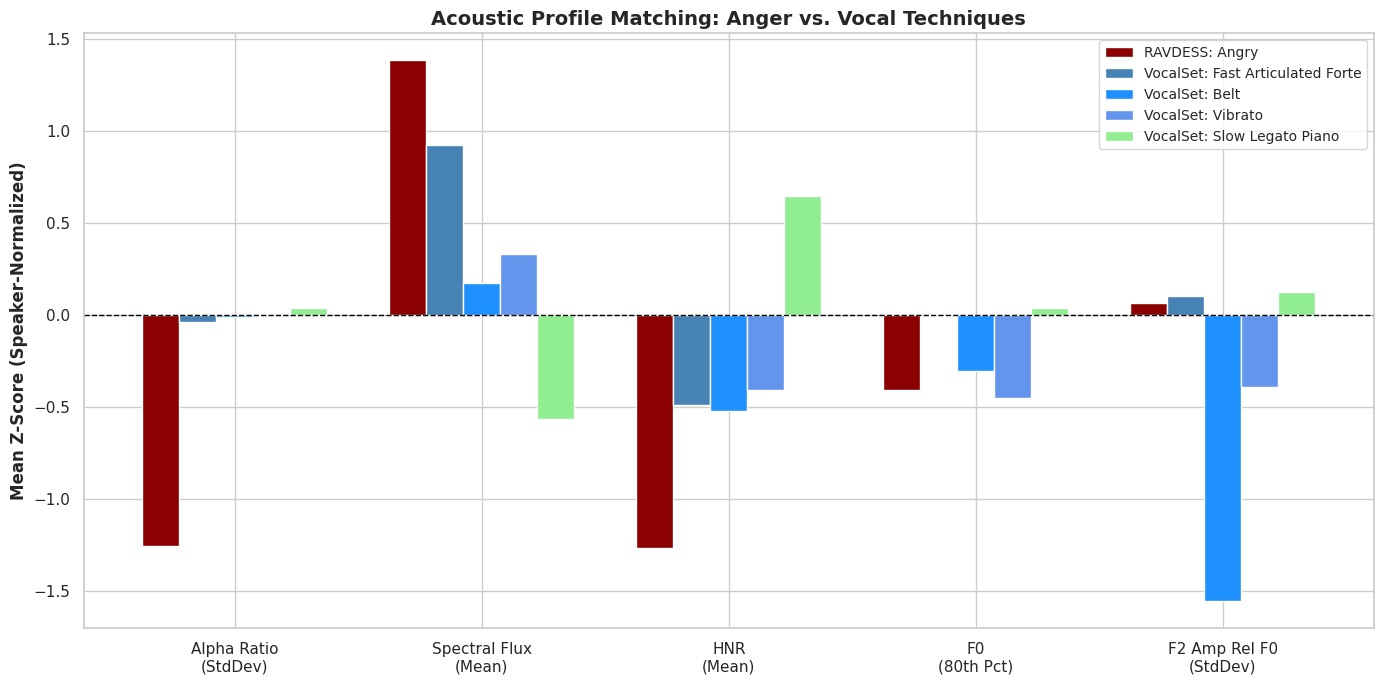

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# top angry features from shap ravdess
top_features_angry = [
    'alphaRatioV_sma3nz_stddevNorm',
    'spectralFlux_sma3_amean',
    'HNRdBACF_sma3nz_amean',
    'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
    'F2amplitudeLogRelF0_sma3nz_stddevNorm'
]

# calculate means for certain techniques
# ravdess baseline
angry_profile = df_ravdess[df_ravdess['emotion'] == 5][top_features_angry].mean()

# vocalset techniques
forte_profile = df_vocalset[df_vocalset['technique'] == 'fast_articulated_forte'][top_features_angry].mean()
belt_profile = df_vocalset[df_vocalset['technique'] == 'belt'][top_features_angry].mean()
vibrato_profile = df_vocalset[df_vocalset['technique'] == 'vibrato'][top_features_angry].mean()

# calm technique to see the difference
piano_profile = df_vocalset[df_vocalset['technique'] == 'slow_legato_piano'][top_features_angry ].mean()


x = np.arange(len(top_features))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))

rects1 = ax.bar(x - 2*width, angry_profile, width, label='RAVDESS: Angry', color='darkred')
rects2 = ax.bar(x - width, forte_profile, width, label='VocalSet: Fast Articulated Forte', color='steelblue')
rects3 = ax.bar(x, belt_profile, width, label='VocalSet: Belt', color='dodgerblue')
rects4 = ax.bar(x + width, vibrato_profile, width, label='VocalSet: Vibrato', color='cornflowerblue')
rects5 = ax.bar(x + 2*width, piano_profile, width, label='VocalSet: Slow Legato Piano', color='lightgreen')

ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.set_ylabel('Mean Z-Score (Speaker-Normalized)', fontsize=12, fontweight='bold')
ax.set_title('Acoustic Profile Matching: Anger vs. Vocal Techniques', fontsize=14, fontweight='bold')
ax.set_xticks(x)

# Νέα, καθαρά labels που αντιστοιχούν ακριβώς στα features
clean_labels = [
    'Alpha Ratio\n(StdDev)',
    'Spectral Flux\n(Mean)',
    'HNR\n(Mean)',
    'F0\n(80th Pct)',
    'F2 Amp Rel F0\n(StdDev)'
]
ax.set_xticklabels(clean_labels, rotation=0, fontsize=11)

ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()
plt.show()

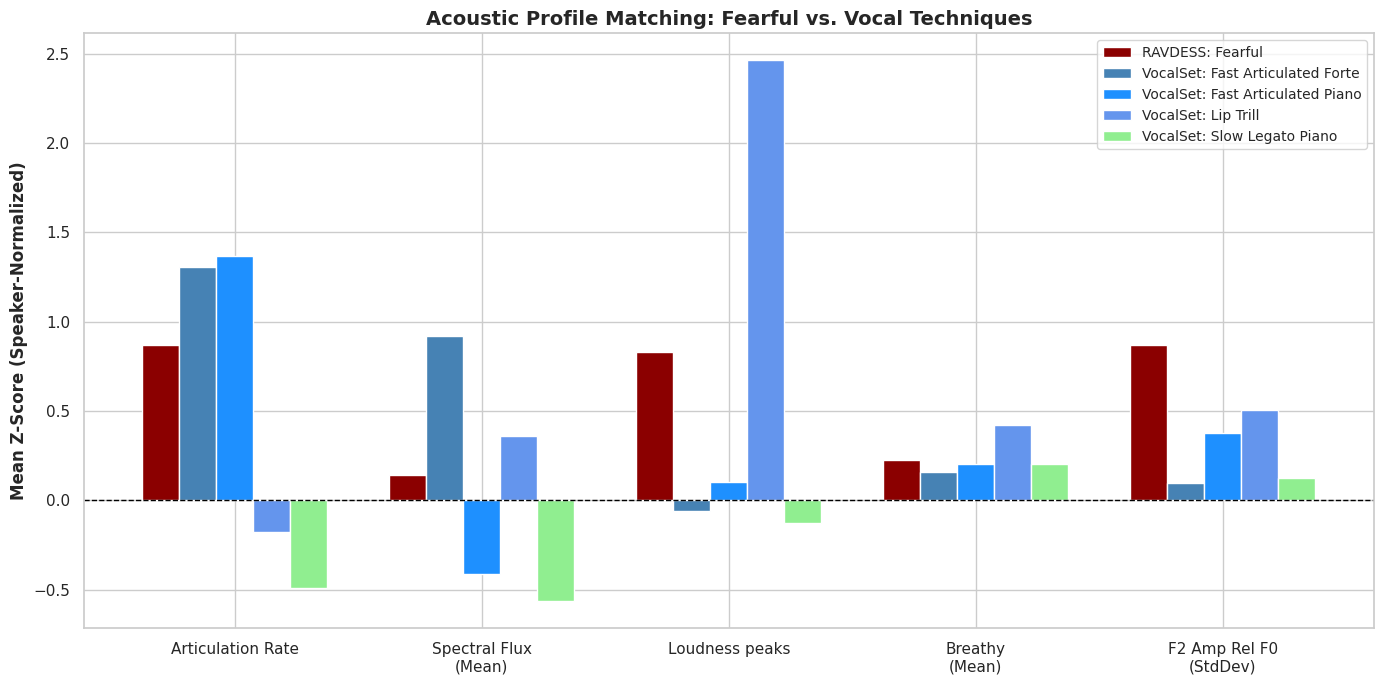

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# top angry features from shap ravdess
top_features_fearful = [
    'articulation_rate',
    'spectralFlux_sma3_amean',
    'loudnessPeaksPerSec',
    'breathy_mean',
    'F2amplitudeLogRelF0_sma3nz_stddevNorm'
]

# calculate means for certain techniques
# ravdess baseline
fearful_profile = df_ravdess[df_ravdess['emotion'] == 6][top_features_fearful].mean()

# vocalset techniques
forte_profile = df_vocalset[df_vocalset['technique'] == 'fast_articulated_forte'][top_features_fearful].mean()
forte_piano_profile = df_vocalset[df_vocalset['technique'] == 'fast_articulated_piano'][top_features_fearful].mean()
lip_trill_profile = df_vocalset[df_vocalset['technique'] == 'lip_trill'][top_features_fearful].mean()

# calm technique to see the difference
piano_profile = df_vocalset[df_vocalset['technique'] == 'slow_legato_piano'][top_features_fearful].mean()


x = np.arange(len(top_features))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))

rects1 = ax.bar(x - 2*width, fearful_profile, width, label='RAVDESS: Fearful', color='darkred')
rects2 = ax.bar(x - width, forte_profile, width, label='VocalSet: Fast Articulated Forte', color='steelblue')
rects3 = ax.bar(x, forte_piano_profile, width, label='VocalSet: Fast Articulated Piano', color='dodgerblue')
rects4 = ax.bar(x + width, lip_trill_profile, width, label='VocalSet: Lip Trill', color='cornflowerblue')
rects5 = ax.bar(x + 2*width, piano_profile, width, label='VocalSet: Slow Legato Piano', color='lightgreen')

ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.set_ylabel('Mean Z-Score (Speaker-Normalized)', fontsize=12, fontweight='bold')
ax.set_title('Acoustic Profile Matching: Fearful vs. Vocal Techniques', fontsize=14, fontweight='bold')
ax.set_xticks(x)

# Νέα, καθαρά labels που αντιστοιχούν ακριβώς στα features
clean_labels = [
    'Articulation Rate',
    'Spectral Flux\n(Mean)',
    'Loudness peaks',
    'Breathy\n(Mean)',
    'F2 Amp Rel F0\n(StdDev)'
]
ax.set_xticklabels(clean_labels, rotation=0, fontsize=11)

ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()
plt.show()

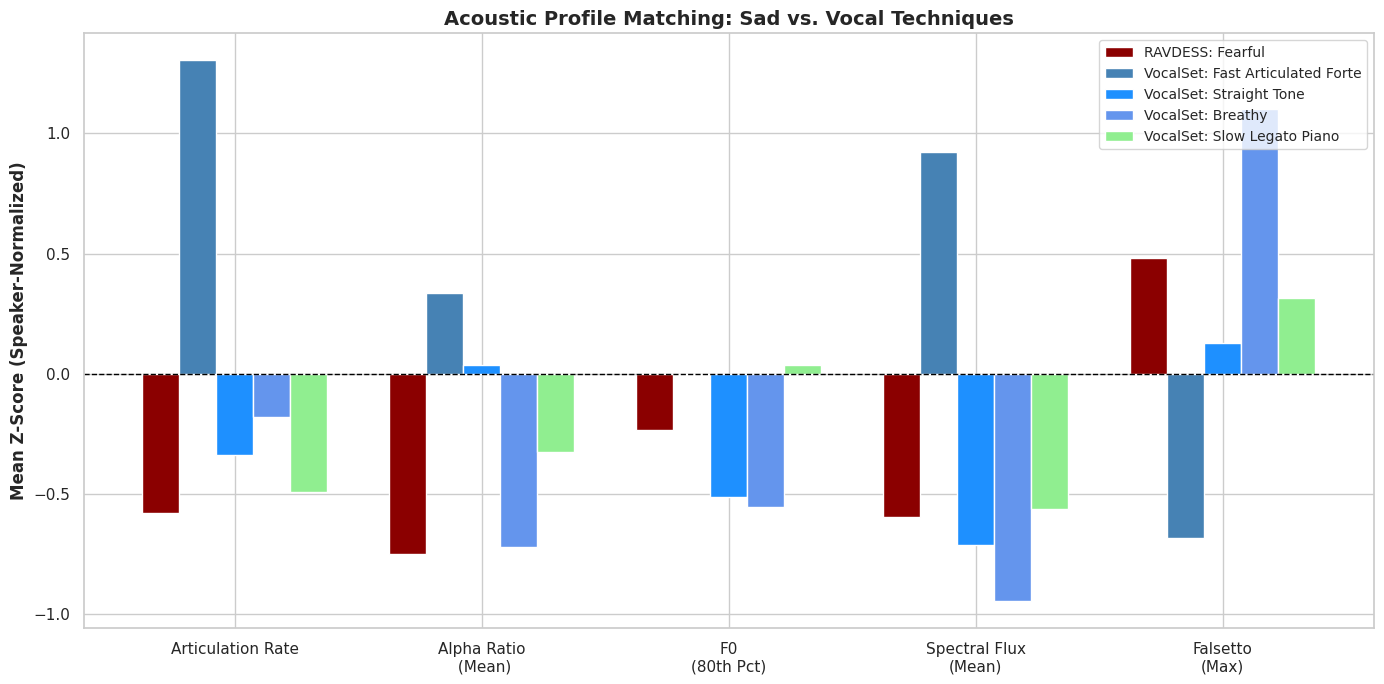

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# top angry features from shap ravdess
top_features_sad = [
    'articulation_rate',
    'alphaRatioV_sma3nz_amean',
    'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
    'spectralFlux_sma3_amean',
    'falsetto_max'
]

# calculate means for certain techniques
# ravdess baseline
sad_profile = df_ravdess[df_ravdess['emotion'] == 4][top_features_sad].mean()

# vocalset techniques
forte_profile = df_vocalset[df_vocalset['technique'] == 'fast_articulated_forte'][top_features_sad].mean()
straight_tone_profile = df_vocalset[df_vocalset['technique'] == 'straight_tone'][top_features_sad].mean()
breathy_profile = df_vocalset[df_vocalset['technique'] == 'breathy'][top_features_sad].mean()

# calm technique to see the difference
piano_profile = df_vocalset[df_vocalset['technique'] == 'slow_legato_piano'][top_features_sad].mean()

x = np.arange(len(top_features_sad))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))

rects1 = ax.bar(x - 2*width, sad_profile, width, label='RAVDESS: Fearful', color='darkred')
rects2 = ax.bar(x - width, forte_profile, width, label='VocalSet: Fast Articulated Forte', color='steelblue')
rects3 = ax.bar(x, straight_tone_profile, width, label='VocalSet: Straight Tone', color='dodgerblue')
rects4 = ax.bar(x + width, breathy_profile, width, label='VocalSet: Breathy', color='cornflowerblue')
rects5 = ax.bar(x + 2*width, piano_profile, width, label='VocalSet: Slow Legato Piano', color='lightgreen')

ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.set_ylabel('Mean Z-Score (Speaker-Normalized)', fontsize=12, fontweight='bold')
ax.set_title('Acoustic Profile Matching: Sad vs. Vocal Techniques', fontsize=14, fontweight='bold')
ax.set_xticks(x)

# Νέα, καθαρά labels που αντιστοιχούν ακριβώς στα features
clean_labels = [
    'Articulation Rate',
    'Alpha Ratio\n (Mean)',
    'F0\n(80th Pct)',
    'Spectral Flux\n(Mean)',
    'Falsetto\n(Max)'
]
ax.set_xticklabels(clean_labels, rotation=0, fontsize=11)

ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()
plt.show()

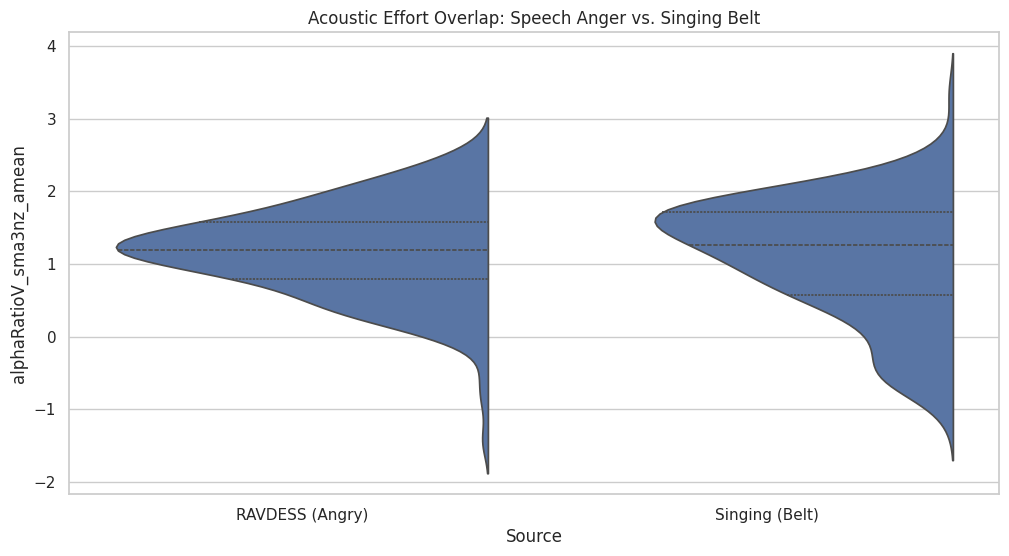

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Φτιάχνουμε ένα προσωρινό dataframe για τη σύγκριση
comp_df = pd.concat([
    df_ravdess[df_ravdess['emotion'] == 5].assign(Source='RAVDESS (Angry)'),
    df_vocalset[df_vocalset['technique'] == 'belt'].assign(Source='Singing (Belt)')
])

plt.figure(figsize=(12, 6))
sns.violinplot(data=comp_df, x='Source', y='alphaRatioV_sma3nz_amean', split=True, inner="quart")
plt.title('Acoustic Effort Overlap: Speech Anger vs. Singing Belt')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_4671/313746044.py:35: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


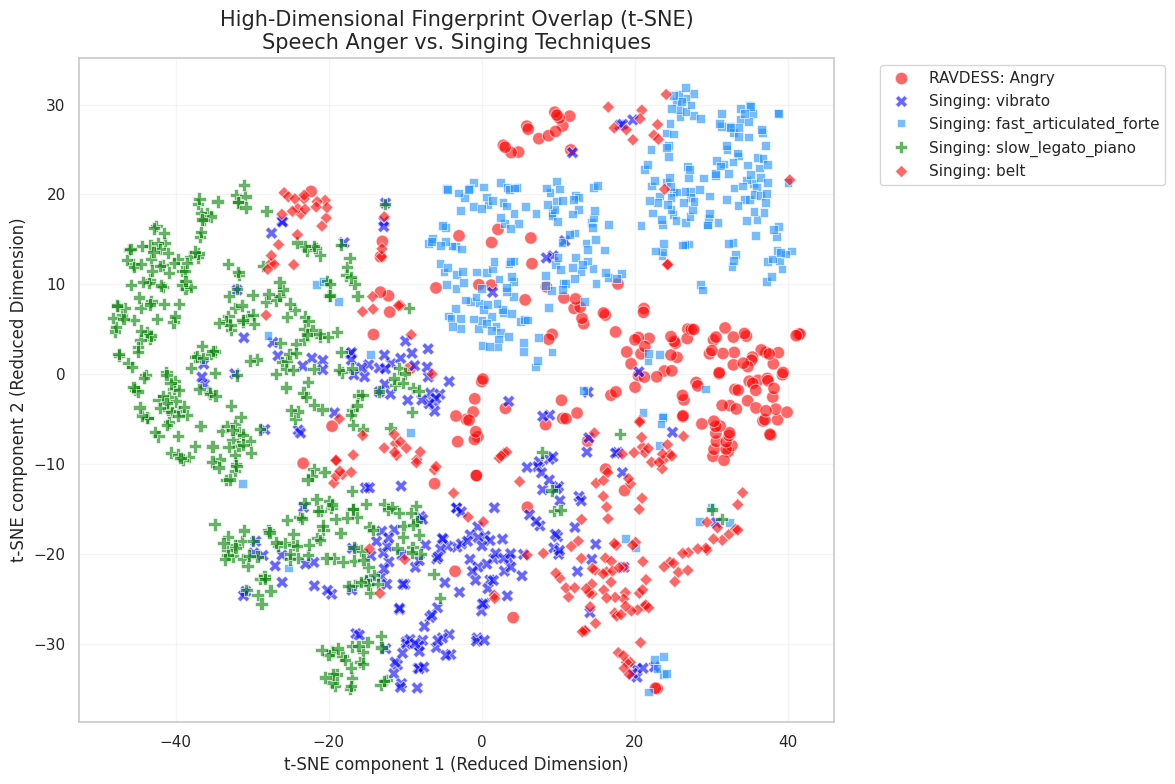

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Προετοιμασία Δεδομένων
# Χρησιμοποιούμε μόνο τα ακουστικά features (expected_features)
df_angry = df_ravdess[df_ravdess['emotion'] == 5][expected_features].copy()
df_angry['Label'] = 'RAVDESS: Angry'

# Επιλογή τεχνικών από VocalSet
techniques_to_compare = ['belt', 'vibrato', 'slow_legato_piano', 'fast_articulated_forte']
df_vocal = df_vocalset[df_vocalset['technique'].isin(techniques_to_compare)].copy()
# Κρατάμε μόνο τα expected_features και τη στήλη Label
df_vocal_subset = df_vocal[expected_features].copy()
df_vocal_subset['Label'] = 'Singing: ' + df_vocal['technique']

# Ενώνουμε τα δεδομένα
combined_df = pd.concat([df_angry, df_vocal_subset], axis=0)
combined_df = combined_df.dropna(subset=expected_features)
# Απομονώνουμε μόνο τα νούμερα για το t-SNE
features_only = combined_df[expected_features]

# 2. Εκτέλεση t-SNE
# Το perplexity 30 είναι καλό standard, αν έχεις λίγα δείγματα δοκίμασε 5-15
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(features_only)

# Προσθήκη των αποτελεσμάτων πίσω στο dataframe
combined_df['tsne-1'] = tsne_results[:,0]
combined_df['tsne-2'] = tsne_results[:,1]

# 3. Σχεδιασμός του Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne-1', y='tsne-2',
    hue='Label',
    style='Label',
    data=combined_df,
    palette=['red', 'blue', 'dodgerblue', 'green'], # Βεβαιώσου ότι τα labels αντιστοιχούν στα χρώματα
    alpha=0.6,
    s=80
)

plt.title('High-Dimensional Fingerprint Overlap (t-SNE)\nRAVDESS Anger vs. Singing Techniques', fontsize=15)
plt.xlabel('t-SNE component 1 (Reduced Dimension)')
plt.ylabel('t-SNE component 2 (Reduced Dimension)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

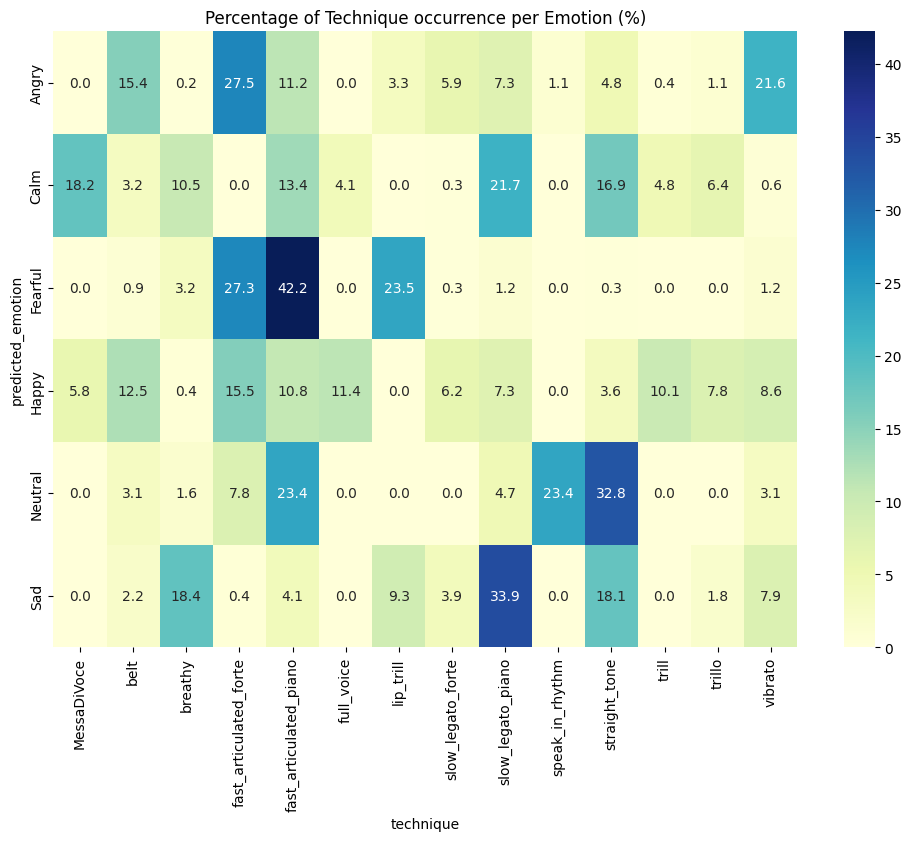

In [ ]:
# Calculate percentage distribution per sentiment
ct_normalized = pd.crosstab(df_vocalset['predicted_emotion'], df_vocalset['technique'], normalize='index') * 100

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(ct_normalized, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Percentage of Technique occurrence per Emotion (%)")
plt.show()

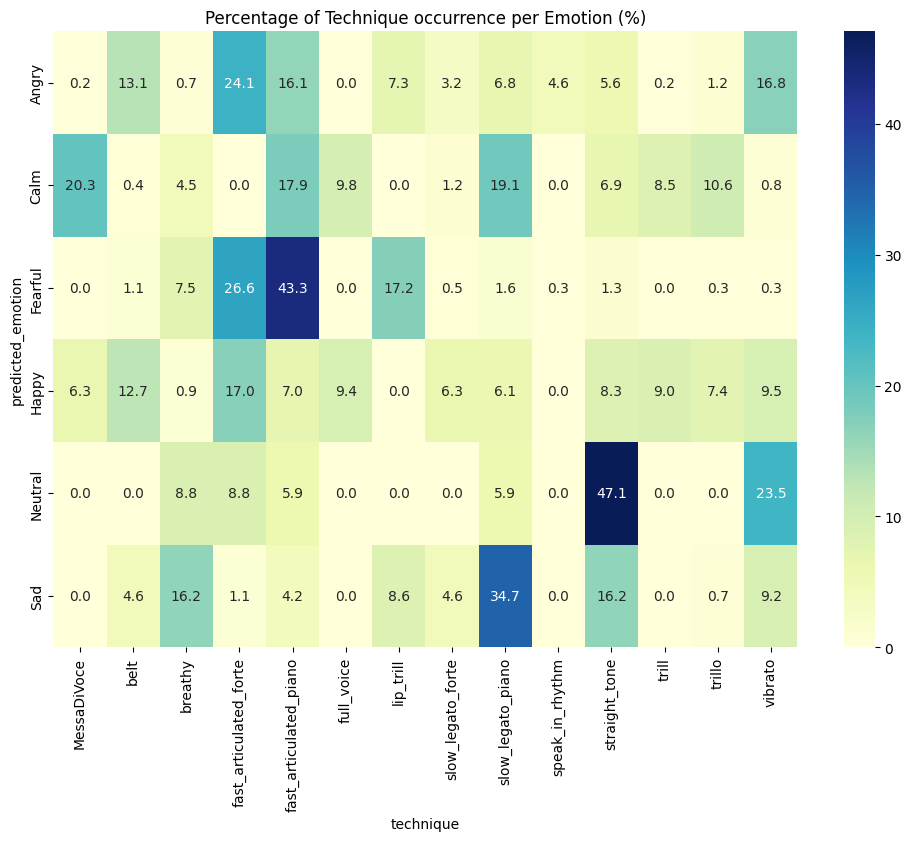

In [ ]:
# Calculate percentage distribution per sentiment for speech
ct_normalized = pd.crosstab(df_vocalset['predicted_emotion'], df_vocalset['technique'], normalize='index') * 100

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(ct_normalized, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Percentage of Technique occurrence per Emotion (%)")
plt.show()

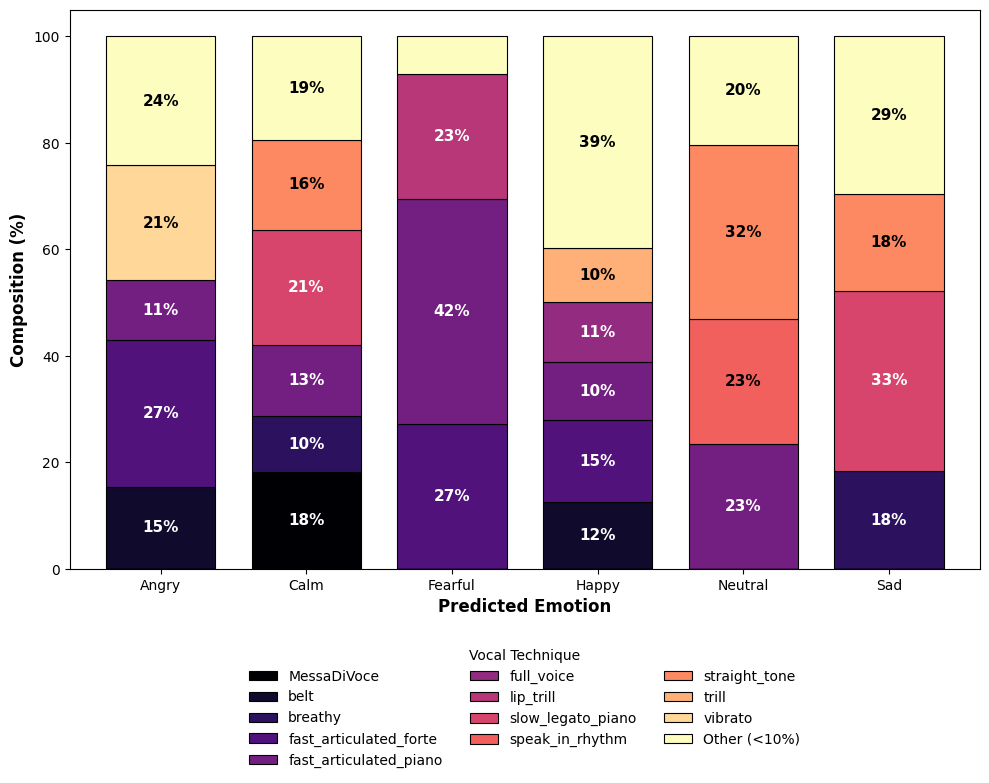

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compute and group < 10%
ct = pd.crosstab(df_vocalset['predicted_emotion'], df_vocalset['technique'], normalize='index') * 100

def group_small_slices(row, threshold=10):
    small_slices = row[row < threshold]
    # Descriptive name for the category
    row['Other (<10%)'] = small_slices.sum()
    row[small_slices.index] = 0
    return row

ct_clean = ct.apply(group_small_slices, axis=1)

# Remove original columns that were zeroed out
ct_clean = ct_clean.loc[:, (ct_clean != 0).any(axis=0)]

# Reorder columns so "Other" is always at the end (top of stack)
cols = [c for c in ct_clean.columns if c != 'Other (<10%)'] + ['Other (<10%)']
ct_clean = ct_clean[cols]

fig, ax = plt.subplots(figsize=(10, 8))

ct_clean.plot(kind='bar',
              stacked=True,
              ax=ax,
              colormap='magma',
              edgecolor='black',
              linewidth=0.8,
              width=0.75)

# Smart labels (only big chunks)
for p in ax.patches:
    h = p.get_height()
    if h > 8:
        # Determine brightness of facecolor to toggle text color
        color_rgb = p.get_facecolor()
        brightness = (color_rgb[0] * 299 + color_rgb[1] * 587 + color_rgb[2] * 114) / 1000
        text_color = "white" if brightness < 0.5 else "black"

        ax.text(p.get_x() + p.get_width()/2.,
                p.get_y() + h/2.,
                f'{int(h)}%',
                ha='center', va='center',
                color=text_color, fontweight='bold', fontsize=11)

# Adjust Legend
ax.legend(title='Vocal Technique',
          loc='upper center',
          bbox_to_anchor=(0.5, -0.12),
          ncol=3,
          fontsize=10,
          frameon=False)

plt.ylabel('Composition (%)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# this is speech only

In [ ]:
import pandas as pd
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from scipy.stats import entropy

# Encode and Calculate Global Scores
df_vocalset['emotion_encoded'] = df_vocalset['predicted_emotion'].astype('category').cat.codes
df_vocalset['tech_encoded'] = df_vocalset['technique'].astype('category').cat.codes

mi = mutual_info_score(df_vocalset['emotion_encoded'], df_vocalset['tech_encoded'])
nmi = normalized_mutual_info_score(df_vocalset['emotion_encoded'], df_vocalset['tech_encoded'])

# Vectorized Analysis per Emotion
# Calculate MI and Entropy
summary_df = df_vocalset.groupby('predicted_emotion').apply(lambda x: pd.Series({
    'MI': mutual_info_score((df_vocalset['predicted_emotion'] == x.name).astype(int), df_vocalset['tech_encoded']),
    'Entropy': entropy(x['technique'].value_counts()) / (entropy([1] * len(x['technique'].unique())) if len(x['technique'].unique()) > 1 else 1)
})).reset_index()

print(f"Total MI: {mi:.4f} | NMI: {nmi:.4f}\n")
print(summary_df)

Total MI: 0.4428 | NMI: 0.2198

  predicted_emotion        MI   Entropy
0             Angry  0.062769  0.822015
1              Calm  0.067552  0.859675
2           Fearful  0.127428  0.609412
3             Happy  0.115784  0.955625
4           Neutral  0.011632  0.813119
5               Sad  0.182393  0.818464


/tmp/ipykernel_30711/3532842987.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_df = df_vocalset.groupby('predicted_emotion').apply(lambda x: pd.Series({


# new features


In [ ]:
import pandas as pd
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from scipy.stats import entropy
# this is with MFDR_vibrato
# Encode and Calculate Global Scores
df_vocalset['emotion_encoded'] = df_vocalset['predicted_emotion'].astype('category').cat.codes
df_vocalset['tech_encoded'] = df_vocalset['technique'].astype('category').cat.codes

mi = mutual_info_score(df_vocalset['emotion_encoded'], df_vocalset['tech_encoded'])
nmi = normalized_mutual_info_score(df_vocalset['emotion_encoded'], df_vocalset['tech_encoded'])

# Vectorized Analysis per Emotion
# Calculate MI and Entropy
summary_df = df_vocalset.groupby('predicted_emotion').apply(lambda x: pd.Series({
    'MI': mutual_info_score((df_vocalset['predicted_emotion'] == x.name).astype(int), df_vocalset['tech_encoded']),
    'Entropy': entropy(x['technique'].value_counts()) / (entropy([1] * len(x['technique'].unique())) if len(x['technique'].unique()) > 1 else 1)
})).reset_index()

print(f"Total MI: {mi:.4f} | NMI: {nmi:.4f}\n")
print(summary_df)

Total MI: 0.4916 | NMI: 0.2406

  predicted_emotion        MI   Entropy
0             Angry  0.081903  0.794538
1              Calm  0.070235  0.859093
2           Fearful  0.134176  0.614160
3             Happy  0.127720  0.945528
4           Neutral  0.031827  0.803073
5               Sad  0.178143  0.801590


/tmp/ipykernel_30711/1632476353.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_df = df_vocalset.groupby('predicted_emotion').apply(lambda x: pd.Series({


# GTSinger

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_gtsinger = pd.read_csv('/content/drive/MyDrive/df_audio_norm_check2.csv')

In [ ]:
import pandas as pd
df_italian = pd.read_csv('/content/drive/MyDrive/df_italian.csv')

In [ ]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

load_path = '/content/drive/MyDrive/ravdess_vocal_final_modelv6.pkl'
package = joblib.load(load_path)

model = package['model']
expected_features = package['feature_names']
class_names = package['class_names']

print("Model loaded successfully!")
print(f"Expected features: {len(expected_features)}: {expected_features}")

Model loaded successfully!
Expected features: 18: ['shimmerLocaldB_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'loudnessPeaksPerSec', 'melodic_deviation', 'HNRdBACF_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_stddevNorm', 'alphaRatioV_sma3nz_stddevNorm', 'spectralFlux_sma3_amean', 'alphaRatioV_sma3nz_amean', 'articulation_rate', 'std_phoneme_duration', 'MFDR_vibrato', 'breathy_mean', 'pharyngeal_max', 'falsetto_max', 'glissando_max', 'tech_entropy']


In [ ]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

load_path = '/content/drive/MyDrive/ravdess_vocal_final_test_speech.pkl'
package = joblib.load(load_path)

model = package['model']
expected_features_speech = package['feature_names']
class_names = package['class_names']

print("Model loaded successfully!")
print(f"Expected features: {len(expected_features_speech)}: {expected_features_speech}")

Model loaded successfully!
Expected features: 19: ['loudness_sma3_percentile80.0', 'loudnessPeaksPerSec', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'shimmerLocaldB_sma3nz_amean', 'shimmerLocaldB_sma3nz_stddevNorm', 'MeanVoicedSegmentLengthSec', 'HNRdBACF_sma3nz_amean', 'alphaRatioV_sma3nz_stddevNorm', 'F2amplitudeLogRelF0_sma3nz_stddevNorm', 'alphaRatioV_sma3nz_amean', 'spectralFluxUV_sma3nz_amean', 'F1bandwidth_sma3nz_stddevNorm', 'logRelF0-H1-A3_sma3nz_amean', 'slopeV0-500_sma3nz_amean', 'F2frequency_sma3nz_stddevNorm', 'articulation_rate', 'std_phoneme_duration']


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score

def perform_loso_cross_validation(df, features_col, target_col, singer_id_col, wav_path_col):
    # Group by perfomance folder
    df['performance_folder'] = df[wav_path_col].apply(lambda x: os.path.dirname(x))

    X = df[features_col].values

    y = df[target_col].values
    groups = df[singer_id_col].values
    performance_ids = df['performance_folder'].values

    n_speakers = len(np.unique(groups))
    gkf = GroupKFold(n_splits=n_speakers)

    perf_accuracies = []
    all_final_preds = []
    all_final_actuals = []
    all_final_styles = [] # Νέα λίστα
    fold_balanced_accs = []
    fold_f1_scores = []

    print(f"LOSO Cross-Validation for {n_speakers} singer...")
    print(f"Calculating Majority Vote per Performance Folder...\n")

    fold = 1
    for train_idx, test_idx in gkf.split(X, y, groups=groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        test_performances = performance_ids[test_idx]

        model = RandomForestClassifier(
          n_estimators=200,
          max_depth=12,         # Higher depth
          min_samples_leaf=10,
          class_weight='balanced',
          random_state=42
      )
        model.fit(X_train, y_train)

        y_pred_segments = model.predict(X_test)

        unique_performances = np.unique(test_performances)
        correct_count = 0
        perf_preds_list = []
        perf_actuals_list = []

        for perf in unique_performances:
            idx = np.where(test_performances == perf)[0]
            perf_preds = y_pred_segments[idx]
            perf_actual = y_test[idx][0]
            style = df[df['performance_folder'] == perf]['singing_method'].iloc[0]

            # Majority Vote
            vals, counts = np.unique(perf_preds, return_counts=True)
            majority_val = vals[np.argmax(counts)]

            perf_preds_list.append(majority_val)
            perf_actuals_list.append(perf_actual)

            all_final_preds.append(majority_val)
            all_final_actuals.append(perf_actual)
            all_final_styles.append(style) # Αποθήκευση στυλ

            if majority_val == perf_actual:
                correct_count += 1

        fold_acc = (correct_count / len(unique_performances)) * 100
        perf_accuracies.append(fold_acc)

        f_bacc = balanced_accuracy_score(perf_actuals_list, perf_preds_list)
        f_f1 = f1_score(perf_actuals_list, perf_preds_list, average='macro')

        fold_balanced_accs.append(f_bacc * 100)
        fold_f1_scores.append(f_f1)

        current_singer = np.unique(groups[test_idx])[0]
        #print(f"Fold {fold} | Test Singer: {current_singer} | Acc: {fold_acc:.2f}%")
        print(f"Fold {fold} | Speaker: {current_singer} | Balanced Acc: {f_bacc*100:.2f}% | F1: {f_f1:.2f}")
        print(f"Detailed Classification Report for fold {fold}:")
        print(classification_report(perf_actuals_list, perf_preds_list))
        fold += 1

    print("\n" + "="*60)
    print(f"FINAL LOSO RESULTS (Majority Vote)")

    mean_bacc = np.mean(fold_balanced_accs)
    std_bacc = np.std(fold_balanced_accs)
    mean_f1 = np.mean(fold_f1_scores)

    print(f"Mean Balanced Accuracy (Per Speaker): {mean_bacc:.2f}%")
    print(f"Inter-Speaker Stability (STD): {std_bacc:.2f}%")
    print(f"Mean F1-score: {mean_f1:.2f}")
    print("="*60)

    # Global Balanced Accuracy
    global_balanced_acc = balanced_accuracy_score(all_final_actuals, all_final_preds)
    print(f"Global Balanced Accuracy: {global_balanced_acc*100:.2f}%")

    # Classification Report
    print("\nDetailed Classification Report (Global Aggregation):")
    print(classification_report(all_final_actuals, all_final_preds))
    return {
        "accuracies": perf_accuracies,
        "y_pred": all_final_preds,
        "y_true": all_final_actuals,
        "mean_acc": np.mean(perf_accuracies),
        "std_acc": np.std(perf_accuracies),
        'style': all_final_styles
    }

In [ ]:
nan_emotions = df_italian[df_italian['emotion'].isna()]['wav_path']

print("Τα wav_path με NaN στην στήλη emotion είναι:")
print(nan_emotions.to_list())

Τα wav_path με NaN στην στήλη emotion είναι:
['/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0000.wav', '/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0001.wav', '/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0002.wav', '/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0003.wav', '/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0004.wav', '/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0005.wav', '/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0006.wav', '/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0007.wav', '/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0008.wav', '/content/GTSinger/Italian/Italian/IT-Bass-1/Breathy/Con ardore/Paired_Speech_Group/0009.wav', '/co

In [ ]:
df_italian.shape

(1842, 160)

In [ ]:
df_italian.singing_method.value_counts()

,count
singing_method,
bel canto,1842


In [ ]:
# Δημιουργεί έναν πίνακα όπου οι γραμμές είναι οι τραγουδιστές
# και οι στήλες είναι τα στυλ
crosstab_result = pd.crosstab(df_gtsinger['unique_singer_id'], df_gtsinger['singing_method'])

print(crosstab_result)

singing_method    bel canto   pop
unique_singer_id                 
DE-Soprano-1           1724     0
DE-Tenor-1             1673     0
EN-Alto-1                 0  1252
EN-Alto-2                 0  1703
EN-Tenor-1                0  1766
FR-Soprano-1              0  1223
FR-Tenor-1             1315     0


In [ ]:
# Δημιουργεί έναν πίνακα όπου οι γραμμές είναι οι τραγουδιστές
# και οι στήλες είναι τα στυλ
crosstab_result = pd.crosstab(df_gtsinger['unique_singer_id'], df_gtsinger['emotion'])

print(crosstab_result)

emotion           happy   sad
unique_singer_id             
DE-Soprano-1        666  1058
DE-Tenor-1         1143   530
EN-Alto-1           525   727
EN-Alto-2           579  1124
EN-Tenor-1          710  1056
FR-Soprano-1        900   323
FR-Tenor-1          990   325


In [ ]:
gtsinger better for de-soprano, en alto 1, en-alto2, fr-tenor-1
ravdess better for fr-soprano-1, en-tenor-1

In [ ]:
results_speech = perform_loso_cross_validation(df_gtsinger, expected_features_speech, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 60.63% | F1: 0.60
Detailed Classification Report for fold 1:
              precision    recall  f1-score   support

       happy       0.61      0.38      0.47        80
         sad       0.66      0.84      0.74       117

    accuracy                           0.65       197
   macro avg       0.64      0.61      0.60       197
weighted avg       0.64      0.65      0.63       197

Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 71.23% | F1: 0.70
Detailed Classification Report for fold 2:
              precision    recall  f1-score   support

       happy       0.60      0.74      0.66        87
         sad       0.80      0.69      0.74       135

    accuracy                           0.71       222
   macro avg       0.70      0.71      0.70       222
weighted avg       0.72      0.71      0.71       222

Fold 3 | Speaker: EN-Alto-2 | Balanced Ac

In [ ]:
results_speech = perform_loso_cross_validation(df_gtsinger, expected_features_speech, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 58.33% | F1: 0.58
Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 68.72% | F1: 0.68
Fold 3 | Speaker: EN-Alto-2 | Balanced Acc: 64.65% | F1: 0.64
Fold 4 | Speaker: DE-Tenor-1 | Balanced Acc: 59.37% | F1: 0.60
Fold 5 | Speaker: FR-Tenor-1 | Balanced Acc: 70.92% | F1: 0.69
Fold 6 | Speaker: EN-Alto-1 | Balanced Acc: 61.86% | F1: 0.60
Fold 7 | Speaker: FR-Soprano-1 | Balanced Acc: 50.48% | F1: 0.50

FINAL LOSO RESULTS (Majority Vote)
Mean Balanced Accuracy (Per Speaker): 62.05%
Inter-Speaker Stability (STD): 6.38%
Mean F1-score: 0.61
Global Balanced Accuracy: 65.01%

Detailed Classification Report (Global Aggregation):
              precision    recall  f1-score   support

       happy       0.66      0.67      0.66       634
         sad       0.64      0.63      0.64       594

    accuracy                           0.65      1228
   macro avg       0.65

In [ ]:
lower, upper = calculate_ci(63.11, 6.84)
print(f"95% CI: ({lower:.2f}, {upper:.2f})")

95% CI: (56.78, 69.44)


In [ ]:
expected_features = ['shimmerLocaldB_sma3nz_amean',
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
 'loudnessPeaksPerSec',
 'melodic_deviation',
 'HNRdBACF_sma3nz_amean',
 'F2amplitudeLogRelF0_sma3nz_stddevNorm',
 'alphaRatioV_sma3nz_stddevNorm',
 'spectralFlux_sma3_amean',
 'alphaRatioV_sma3nz_amean',
 'articulation_rate',
 'std_phoneme_duration',
 'MFDR_vibrato',
 'breathy_mean',
 'pharyngeal_max',
 'falsetto_max',
 'glissando_max']

In [ ]:
results_ravdess = perform_loso_cross_validation(df_gtsinger, expected_features, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 62.58% | F1: 0.61
Detailed Classification Report for fold 1:
              precision    recall  f1-score   support

       happy       0.52      0.69      0.59        80
         sad       0.73      0.56      0.63       117

    accuracy                           0.61       197
   macro avg       0.62      0.63      0.61       197
weighted avg       0.64      0.61      0.62       197

Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 58.29% | F1: 0.55
Detailed Classification Report for fold 2:
              precision    recall  f1-score   support

       happy       0.81      0.20      0.31        87
         sad       0.65      0.97      0.78       135

    accuracy                           0.67       222
   macro avg       0.73      0.58      0.55       222
weighted avg       0.71      0.67      0.60       222

Fold 3 | Speaker: EN-Alto-2 | Balanced Ac

In [ ]:
results_ravdess = perform_loso_cross_validation(df_gtsinger, expected_features, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 63.40% | F1: 0.62
Detailed Classification Report for fold 1:
              precision    recall  f1-score   support

       happy       0.52      0.71      0.60        80
         sad       0.74      0.56      0.63       117

    accuracy                           0.62       197
   macro avg       0.63      0.63      0.62       197
weighted avg       0.65      0.62      0.62       197

Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 57.92% | F1: 0.54
Detailed Classification Report for fold 2:
              precision    recall  f1-score   support

       happy       0.77      0.20      0.31        87
         sad       0.65      0.96      0.78       135

    accuracy                           0.66       222
   macro avg       0.71      0.58      0.54       222
weighted avg       0.70      0.66      0.59       222

Fold 3 | Speaker: EN-Alto-2 | Balanced Ac

In [ ]:
results_ravdess = perform_loso_cross_validation(df_gtsinger, expected_features, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 63.40% | F1: 0.62
Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 57.92% | F1: 0.54
Fold 3 | Speaker: EN-Alto-2 | Balanced Acc: 60.97% | F1: 0.60
Fold 4 | Speaker: DE-Tenor-1 | Balanced Acc: 58.93% | F1: 0.53
Fold 5 | Speaker: FR-Tenor-1 | Balanced Acc: 54.81% | F1: 0.55
Fold 6 | Speaker: EN-Alto-1 | Balanced Acc: 60.17% | F1: 0.49
Fold 7 | Speaker: FR-Soprano-1 | Balanced Acc: 57.87% | F1: 0.51

FINAL LOSO RESULTS (Majority Vote)
Mean Balanced Accuracy (Per Speaker): 59.15%
Inter-Speaker Stability (STD): 2.52%
Mean F1-score: 0.55
Global Balanced Accuracy: 60.10%

Detailed Classification Report (Global Aggregation):
              precision    recall  f1-score   support

       happy       0.63      0.55      0.59       634
         sad       0.58      0.65      0.61       594

    accuracy                           0.60      1228
   macro avg       0.60

In [ ]:
import math

def calculate_ci(mean_bacc, std, n_speakers=7):
    t = 2.447  # t-score για 95% CI και 6 degrees of freedom
    margin_of_error = t * (std / math.sqrt(n_speakers))

    lower_bound = mean_bacc - margin_of_error
    upper_bound = mean_bacc + margin_of_error

    return lower_bound, upper_bound


In [ ]:
lower, upper = calculate_ci(59.15, 2.52)
print(f"95% CI: ({lower:.2f}, {upper:.2f})")

95% CI: (56.82, 61.48)


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, balanced_accuracy_score
from collections import Counter
from collections import defaultdict

def perform_nested_loso_rf(df, categories_list, target_col, singer_id_col, wav_path_col, total_top_k=20):
    df = df.copy()

    # Δημιουργία performance folder για το Majority Voting
    df['performance_folder'] = df[wav_path_col].apply(lambda x: os.path.dirname(x))

    # Ενοποίηση όλων των features σε μια λίστα

    all_features = [f for sublist in categories_list.values() for f in sublist]
    groups = df[singer_id_col]
    y = df[target_col].values

    logo_outer = LeaveOneGroupOut()

    all_final_preds = []
    all_final_actuals = []
    selected_features_per_fold = []
    feature_importances_per_fold = []

    print(f"Starting Nested LOSO with Global Feature Selection ({groups.nunique()} singers)")

    # --- OUTER LOOP ---
    for fold, (train_idx, test_idx) in enumerate(logo_outer.split(df[all_features], y, groups), 1):
        df_train = df.iloc[train_idx].reset_index(drop=True)
        df_test = df.iloc[test_idx].reset_index(drop=True)

        test_singer = df_test[singer_id_col].iloc[0]
        print(f"\nFold {fold}: Testing on Singer {test_singer}")

        # --- INNER LOOP: Feature Selection ---
        print(f"   --- Running Inner Feature Selection (Stability Check)...")
        inner_feature_counter = Counter()
        logo_inner = LeaveOneGroupOut()

        inner_groups = df_train[singer_id_col].values
        inner_y = df_train[target_col].values
        X_inner_all = df_train[all_features]

        inner_importance_sum = defaultdict(float)

        for i_train_idx, i_val_idx in logo_inner.split(X_inner_all, inner_y, inner_groups):
            X_i_train, y_i_train = X_inner_all.iloc[i_train_idx], inner_y[i_train_idx]

            # Shallow RF για υπολογισμό importance
            rf_inner = RandomForestClassifier(n_estimators=50, max_depth=6, random_state=42, class_weight='balanced')
            rf_inner.fit(X_i_train, y_i_train)

            # Feature Importance DataFrame
            inner_importance = pd.DataFrame({'feat': all_features, 'imp': rf_inner.feature_importances_})

            # ΕΔΩ Η ΑΛΛΑΓΗ: Παίρνουμε τα top K ανεξαρτήτως κατηγορίας σε κάθε inner fold
            top_k_inner = inner_importance.sort_values(by='imp', ascending=False).head(total_top_k)
            inner_feature_counter.update(top_k_inner['feat'].tolist())

            fold_importances = dict(zip(all_features, rf_inner.feature_importances_))
            # Προσθέτουμε στο συνολικό άθροισμα
            for feat, imp in fold_importances.items():
              inner_importance_sum[feat] += imp


        # ΕΔΩ Η ΑΛΛΑΓΗ: Επιλογή των τελικών top K χαρακτηριστικών που ψήφισαν τα περισσότερα inner folds
        # Το most_common(n) επιστρέφει τα n πιο συχνά στοιχεία
        final_selected_features = [f for f, count in inner_feature_counter.most_common(total_top_k)]
        final_sel_feats_imps    = {feat: inner_importance_sum[feat] for feat in final_selected_features}

        selected_features_per_fold.append(final_selected_features)
        feature_importances_per_fold.append(final_sel_feats_imps)

        print(f"   --- Selected top {len(final_selected_features)} most stable features:")
        print(final_sel_feats_imps)

        # --- FINAL TRAIN & TEST (Outer Fold) ---
        X_train_final = df_train[final_selected_features]
        y_train_final = df_train[target_col]

        X_test_final = df_test[final_selected_features]
        y_test_final = df_test[target_col]
        test_performances = df_test['performance_folder'].values

        final_rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, class_weight='balanced')
        final_rf.fit(X_train_final, y_train_final)

        y_pred_segments = final_rf.predict(X_test_final)

        # --- MAJORITY VOTING ---
        unique_perfs = np.unique(test_performances)
        for perf in unique_perfs:
            perf_idx = np.where(test_performances == perf)[0]
            vals, counts = np.unique(y_pred_segments[perf_idx], return_counts=True)
            majority_val = vals[np.argmax(counts)]

            all_final_preds.append(majority_val)
            all_final_actuals.append(y_test_final.iloc[perf_idx[0]])

    print("\n" + "="*40)
    print()
    print("FINAL NESTED LOSO RESULTS (Per Performance)")
    print("="*40)
    # Χρήση Balanced Accuracy λόγω του imbalance που είδαμε πριν
    bacc = balanced_accuracy_score(all_final_actuals, all_final_preds)
    print(f"Balanced Accuracy: {bacc*100:.2f}%")
    print("-" * 40)
    print(classification_report(all_final_actuals, all_final_preds))

    return selected_features_per_fold, feature_importances_per_fold

In [ ]:
df_gtsinger.columns.to_list()

['Unnamed: 0',
 'wav_path',
 'emotion',
 'pace',
 'range_label',
 'singing_method',
 'language',
 'range_folder',
 'technique_folder',
 'song_title',
 'group_folder',
 'json_file',
 'lyrics',
 'unique_singer_id',
 'F0semitoneFrom27.5Hz_sma3nz_amean',
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
 'loudness_sma3_amean',
 'loudness_sma3_stddevNorm',
 'loudness_sma3_percentile20.0',
 'loudness_sma3_percentile50.0',
 'loudness_sma3_percentile80.0',
 'loudness_sma3_pctlrange0-2',
 'loudness_sma3_meanRisingSlope',
 'loudness_sma3_stddevRisingSlope',
 'loudness_sma3_meanFallingSlope',
 'loudness_sma3_stddevFallingSlope

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier

prosodic = ['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
            'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
            'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
            'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
            'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
            'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',
            'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2',
            'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope',
            'loudness_sma3_stddevFallingSlope', 'loudnessPeaksPerSec', 'VoicedSegmentsPerSec',
            'MeanVoicedSegmentLengthSec', 'StddevVoicedSegmentLengthSec', 'MeanUnvoicedSegmentLength',
            'StddevUnvoicedSegmentLength', 'equivalentSoundLevel_dBp', 'delta_energy_mean',
            'delta_energy_std', 'delta_pitch_std', 'delta_pitch_mean', 'st_loudness_variability', 'lt_loudness_variability',
            'jitterLocal_sma3nz_amean',
            'pitch_variability', 'melodic_deviation', 'dett_mean', 'dett_std', 'dett_cv', 'pitch_bias',
            'jitterLocal_sma3nz_stddevNorm', 'shimmerLocaldB_sma3nz_amean', 'shimmerLocaldB_sma3nz_stddevNorm']

spectral = ['spectralFlux_sma3_amean', 'spectralFlux_sma3_stddevNorm',
            'HNRdBACF_sma3nz_amean', 'HNRdBACF_sma3nz_stddevNorm', 'logRelF0-H1-H2_sma3nz_amean',
            'logRelF0-H1-H2_sma3nz_stddevNorm', 'logRelF0-H1-A3_sma3nz_amean', 'logRelF0-H1-A3_sma3nz_stddevNorm',
            'F1frequency_sma3nz_amean', 'F1frequency_sma3nz_stddevNorm', 'F1bandwidth_sma3nz_amean',
            'F1bandwidth_sma3nz_stddevNorm', 'F1amplitudeLogRelF0_sma3nz_amean', 'F1amplitudeLogRelF0_sma3nz_stddevNorm',
            'F2frequency_sma3nz_amean', 'F2frequency_sma3nz_stddevNorm', 'F2bandwidth_sma3nz_amean',
            'F2bandwidth_sma3nz_stddevNorm', 'F2amplitudeLogRelF0_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_stddevNorm',
            'F3frequency_sma3nz_amean', 'F3frequency_sma3nz_stddevNorm', 'F3bandwidth_sma3nz_amean',
            'F3bandwidth_sma3nz_stddevNorm', 'F3amplitudeLogRelF0_sma3nz_amean', 'F3amplitudeLogRelF0_sma3nz_stddevNorm',
            'alphaRatioV_sma3nz_amean', 'alphaRatioV_sma3nz_stddevNorm', 'hammarbergIndexV_sma3nz_amean',
            'hammarbergIndexV_sma3nz_stddevNorm', 'slopeV0-500_sma3nz_amean', 'slopeV0-500_sma3nz_stddevNorm',
            'slopeV500-1500_sma3nz_amean', 'slopeV500-1500_sma3nz_stddevNorm', 'spectralFluxV_sma3nz_amean',
            'spectralFluxV_sma3nz_stddevNorm', 'alphaRatioUV_sma3nz_amean', 'hammarbergIndexUV_sma3nz_amean',
            'slopeUV0-500_sma3nz_amean', 'slopeUV500-1500_sma3nz_amean', 'spectralFluxUV_sma3nz_amean',
            'spectral_flatness_mean', 'spectral_flatness_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'zcr_mean', 'zcr_std',
            ]

phonemes = ['phoneme_duration_cv',
            'articulation_rate',
            'vowel_ratio',
            'avg_distance_pauses',
            'mean_pause_duration',
            'std_pause_duration',
            'mean_phoneme_duration',
            'std_phoneme_duration',
            'pause_ratio']

techniques = ['vibrato_mean', 'vibrato_std', 'vibrato_max',
              'vibrato_peak_factor', 'mix_mean', 'mix_std', 'mix_max',
              'mix_peak_factor', 'falsetto_mean', 'falsetto_std', 'falsetto_max',
              'falsetto_peak_factor', 'breathy_mean', 'breathy_std', 'breathy_max',
              'breathy_peak_factor', 'pharyngeal_mean', 'pharyngeal_std',
              'pharyngeal_max', 'pharyngeal_peak_factor', 'glissando_mean',
              'glissando_std', 'glissando_max', 'glissando_peak_factor',
              'num_tech_changes', 'tech_entropy', 'MFDR_slow',
              'MFDR_vibrato',
              'MFDR_high',
              'MFDR_slow2vibrato',
              'MFDR_vibrato2high']

all_features = prosodic + spectral + phonemes + techniques

In [ ]:
categories = {
    #'prosodic': prosodic,
    #'spectral': spectral,
    'phonemes': phonemes,
    'techniques': techniques
}

In [ ]:
singing_combo = perform_nested_loso_rf(df_gtsinger, categories, 'emotion', 'unique_singer_id', 'wav_path', 15)

Starting Nested LOSO with Global Feature Selection (7 singers)

Fold 1: Testing on Singer DE-Soprano-1
   --- Running Inner Feature Selection (Stability Check)...
   --- Selected top 15 most stable features:
{'articulation_rate': np.float64(0.2886942183258636), 'mean_phoneme_duration': np.float64(0.3023752795179893), 'std_phoneme_duration': np.float64(0.25621466554617245), 'pharyngeal_std': np.float64(0.44563405142474316), 'pharyngeal_mean': np.float64(0.3111012043114233), 'falsetto_mean': np.float64(0.2183362280567455), 'vibrato_peak_factor': np.float64(0.21639732546394372), 'vibrato_max': np.float64(0.22465588270843492), 'phoneme_duration_cv': np.float64(0.1792270466845147), 'pharyngeal_max': np.float64(0.2513881862483162), 'pharyngeal_peak_factor': np.float64(0.3912818958055535), 'glissando_mean': np.float64(0.1705703070133392), 'vibrato_std': np.float64(0.17121305210937013), 'falsetto_max': np.float64(0.21988776787279052), 'falsetto_std': np.float64(0.15864196514305015)}

Fold 2: T

In [ ]:
from collections import defaultdict
import pandas as pd
import numpy as np

def get_feature_stability_ranking(selected_features_per_fold):
    """
    Δέχεται τη λίστα από dicts (με 'features' και 'importances')
    και υπολογίζει στατιστικά σταθερότητας και σπουδαιότητας.
    """
    # Δομές για αποθήκευση
    feat_counts = defaultdict(int)
    feat_importances = defaultdict(list)

    total_folds = len(selected_features_per_fold)

    # 1. Συγκέντρωση δεδομένων
    for fold_data in selected_features_per_fold:
        feats = list(fold_data.keys())

        for feat in feats:
            feat_counts[feat] += 1
            feat_importances[feat].append(fold_data[feat])

    # 2. Υπολογισμός στατιστικών
    ranking_data = []
    for feat in feat_counts:
        freq = feat_counts[feat]
        imps = feat_importances[feat]

        mean_imp = np.mean(imps)
        std_imp = np.std(imps) if len(imps) > 1 else 0

        ranking_data.append({
            'Feature': feat,
            'Frequency': freq,
            'Selection_Rate (%)': (freq / total_folds) * 100,
            'Mean_Importance': mean_imp,
            'Std_Importance': std_imp,
            # Stability Score: Συχνότητα * Μέση Σπουδαιότητα
            'Stability_Score': (freq / total_folds) * mean_imp,
            'CV': mean_imp/std_imp
        })

    # 3. Δημιουργία DataFrame και ταξινόμηση
    df_ranking = pd.DataFrame(ranking_data)
    df_ranking = df_ranking.sort_values(by='Stability_Score', ascending=False).reset_index(drop=True)

    return df_ranking

In [ ]:
ranking_df = get_feature_stability_ranking(singing_combo[1])
print(ranking_df) # Τα 10 πιο σταθερά χαρακτηριστικά

                   Feature  Frequency  Selection_Rate (%)  Mean_Importance  \
0    mean_phoneme_duration          7          100.000000         0.507220   
1        articulation_rate          7          100.000000         0.450767   
2           pharyngeal_std          7          100.000000         0.436419   
3     std_phoneme_duration          7          100.000000         0.316015   
4   pharyngeal_peak_factor          6           85.714286         0.355059   
5           pharyngeal_max          7          100.000000         0.250974   
6          pharyngeal_mean          6           85.714286         0.265234   
7              vibrato_max          6           85.714286         0.220579   
8      phoneme_duration_cv          6           85.714286         0.205941   
9      vibrato_peak_factor          6           85.714286         0.194971   
10             vibrato_std          6           85.714286         0.188087   
11           falsetto_mean          5           71.428571       

/tmp/ipykernel_5207/2706864481.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  'CV': mean_imp/std_imp


In [ ]:
categories = {
    'prosodic': prosodic,
    'spectral': spectral,
    #'phonemes': phonemes,
    'techniques': techniques
}

In [ ]:
all = perform_nested_loso_rf(df_gtsinger, categories, 'emotion', 'unique_singer_id', 'wav_path', 20)

Starting Nested LOSO with Global Feature Selection (7 singers)

Fold 1: Testing on Singer DE-Soprano-1
   --- Running Inner Feature Selection (Stability Check)...
   --- Selected top 20 most stable features:
{'mean_phoneme_duration': np.float64(0.12976089663460508), 'articulation_rate': np.float64(0.12770340765078633), 'vibrato_max': np.float64(0.17389131351980766), 'pharyngeal_max': np.float64(0.2549721396752876), 'vibrato_std': np.float64(0.1415743615458604), 'pharyngeal_peak_factor': np.float64(0.18271007308726267), 'pharyngeal_std': np.float64(0.1629422624267049), 'falsetto_std': np.float64(0.1797868236025115), 'vibrato_peak_factor': np.float64(0.17030911554046432), 'std_phoneme_duration': np.float64(0.13306730216893942), 'pharyngeal_mean': np.float64(0.16774088856280084), 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0': np.float64(0.11271610988320178), 'falsetto_max': np.float64(0.15749188571369221), 'breathy_peak_factor': np.float64(0.10359232295886209), 'slopeUV0-500_sma3nz_amean':

In [ ]:
ranking_df = get_feature_stability_ranking(all[1])
print(ranking_df) # Τα 10 πιο σταθερά χαρακτηριστικά

                                       Feature  Frequency  Selection_Rate (%)  \
0                        mean_phoneme_duration          7          100.000000   
1                               pharyngeal_max          7          100.000000   
2                            articulation_rate          7          100.000000   
3                               pharyngeal_std          7          100.000000   
4                       pharyngeal_peak_factor          6           85.714286   
5                         std_phoneme_duration          7          100.000000   
6                          vibrato_peak_factor          7          100.000000   
7                                  vibrato_max          7          100.000000   
8                                 falsetto_std          7          100.000000   
9                              pharyngeal_mean          6           85.714286   
10                                 vibrato_std          7          100.000000   
11                         l

/tmp/ipykernel_5207/2706864481.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  'CV': mean_imp/std_imp


In [ ]:
combo2 = perform_nested_loso_rf(df_gtsinger, categories, 'emotion', 'unique_singer_id', 'wav_path', 20)

Starting Nested LOSO with Global Feature Selection (7 singers)

Fold 1: Testing on Singer DE-Soprano-1
   --- Running Inner Feature Selection (Stability Check)...
   --- Selected top 20 most stable features:
{'vibrato_max': np.float64(0.23990658393745498), 'pharyngeal_mean': np.float64(0.3449058274811962), 'pharyngeal_std': np.float64(0.201670637558754), 'pharyngeal_max': np.float64(0.1755764394344003), 'falsetto_mean': np.float64(0.15337563818627212), 'loudnessPeaksPerSec': np.float64(0.09632839481810015), 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0': np.float64(0.09552230690752607), 'pharyngeal_peak_factor': np.float64(0.15752160776134283), 'vibrato_std': np.float64(0.11339952743255928), 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0': np.float64(0.11445024940138389), 'falsetto_std': np.float64(0.14398108954741212), 'vibrato_peak_factor': np.float64(0.132883083684201), 'breathy_std': np.float64(0.1055456193004247), 'spectralFluxV_sma3nz_amean': np.float64(0.07861197163073437), 'breathy_

In [ ]:
ranking_df = get_feature_stability_ranking(combo2[1])
print(ranking_df) # Τα 10 πιο σταθερά χαρακτηριστικά

                                       Feature  Frequency  Selection_Rate (%)  \
0                              pharyngeal_mean          7          100.000000   
1                                  vibrato_max          7          100.000000   
2                               pharyngeal_std          7          100.000000   
3                          loudnessPeaksPerSec          7          100.000000   
4                               pharyngeal_max          7          100.000000   
5                  shimmerLocaldB_sma3nz_amean          6           85.714286   
6                       pharyngeal_peak_factor          6           85.714286   
7                                 falsetto_std          6           85.714286   
8                                falsetto_mean          6           85.714286   
9                                  vibrato_std          7          100.000000   
10                                vibrato_mean          5           71.428571   
11                  HNRdBACF

/tmp/ipykernel_5207/2706864481.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  'CV': mean_imp/std_imp


In [ ]:
best_techniques = [
    'pharyngeal_max', 'mix_max',
    'vibrato_peak_factor', 'vibrato_max', 'falsetto_std', 'breathy_std'
  ]

best_phonemes = [
    'articulation_rate',
    'std_phoneme_duration'
]
best_spectral = [
    'alphaRatioV_sma3nz_stddevNorm',
    'slopeV0-500_sma3nz_stddevNorm',
    'logRelF0-H1-H2_sma3nz_stddevNorm',
    'HNRdBACF_sma3nz_stddevNorm',
    'logRelF0-H1-A3_sma3nz_stddevNorm'
]

best_prosody = [
    'loudnessPeaksPerSec',
    'VoicedSegmentsPerSec',
    #'MeanVoicedSegmentLengthSec',
    'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
    'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
    'shimmerLocaldB_sma3nz_amean', 'jitterLocal_sma3nz_amean'
]

selected_feats = best_techniques + best_phonemes + best_spectral + best_prosody
print(len(best_prosody), len(best_spectral), len(best_phonemes), len(best_techniques))
print(len(selected_feats))

6 5 2 6
19


In [ ]:
results_gtsinger = perform_loso_cross_validation(df_gtsinger, selected_feats, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 61.10% | F1: 0.61
Detailed Classification Report for fold 1:
              precision    recall  f1-score   support

       happy       0.55      0.51      0.53        80
         sad       0.68      0.71      0.69       117

    accuracy                           0.63       197
   macro avg       0.61      0.61      0.61       197
weighted avg       0.63      0.63      0.63       197

Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 67.48% | F1: 0.68
Detailed Classification Report for fold 2:
              precision    recall  f1-score   support

       happy       0.89      0.38      0.53        87
         sad       0.71      0.97      0.82       135

    accuracy                           0.74       222
   macro avg       0.80      0.67      0.68       222
weighted avg       0.78      0.74      0.71       222

Fold 3 | Speaker: EN-Alto-2 | Balanced Ac

In [ ]:
results_gtsinger = perform_loso_cross_validation(df_gtsinger, selected_feats, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 61.29% | F1: 0.61
Detailed Classification Report for fold 1:
              precision    recall  f1-score   support

       happy       0.55      0.53      0.54        80
         sad       0.68      0.70      0.69       117

    accuracy                           0.63       197
   macro avg       0.61      0.61      0.61       197
weighted avg       0.63      0.63      0.63       197

Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 62.68% | F1: 0.61
Detailed Classification Report for fold 2:
              precision    recall  f1-score   support

       happy       0.89      0.28      0.42        87
         sad       0.68      0.98      0.80       135

    accuracy                           0.70       222
   macro avg       0.78      0.63      0.61       222
weighted avg       0.76      0.70      0.65       222

Fold 3 | Speaker: EN-Alto-2 | Balanced Ac

In [ ]:
results_gtsinger = perform_loso_cross_validation(df_gtsinger, selected_feats, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 61.29% | F1: 0.61
Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 62.68% | F1: 0.61
Fold 3 | Speaker: EN-Alto-2 | Balanced Acc: 62.78% | F1: 0.61
Fold 4 | Speaker: DE-Tenor-1 | Balanced Acc: 59.65% | F1: 0.60
Fold 5 | Speaker: FR-Tenor-1 | Balanced Acc: 55.78% | F1: 0.52
Fold 6 | Speaker: EN-Alto-1 | Balanced Acc: 62.66% | F1: 0.58
Fold 7 | Speaker: FR-Soprano-1 | Balanced Acc: 56.57% | F1: 0.50

FINAL LOSO RESULTS (Majority Vote)
Mean Balanced Accuracy (Per Speaker): 60.20%
Inter-Speaker Stability (STD): 2.75%
Mean F1-score: 0.58
Global Balanced Accuracy: 62.74%

Detailed Classification Report (Global Aggregation):
              precision    recall  f1-score   support

       happy       0.65      0.59      0.62       634
         sad       0.60      0.66      0.63       594

    accuracy                           0.63      1228
   macro avg       0.63

In [ ]:
lower, upper = calculate_ci(59.94, 2.51)
print(f"95% CI: ({lower:.2f}, {upper:.2f})")

95% CI: (57.62, 62.26)


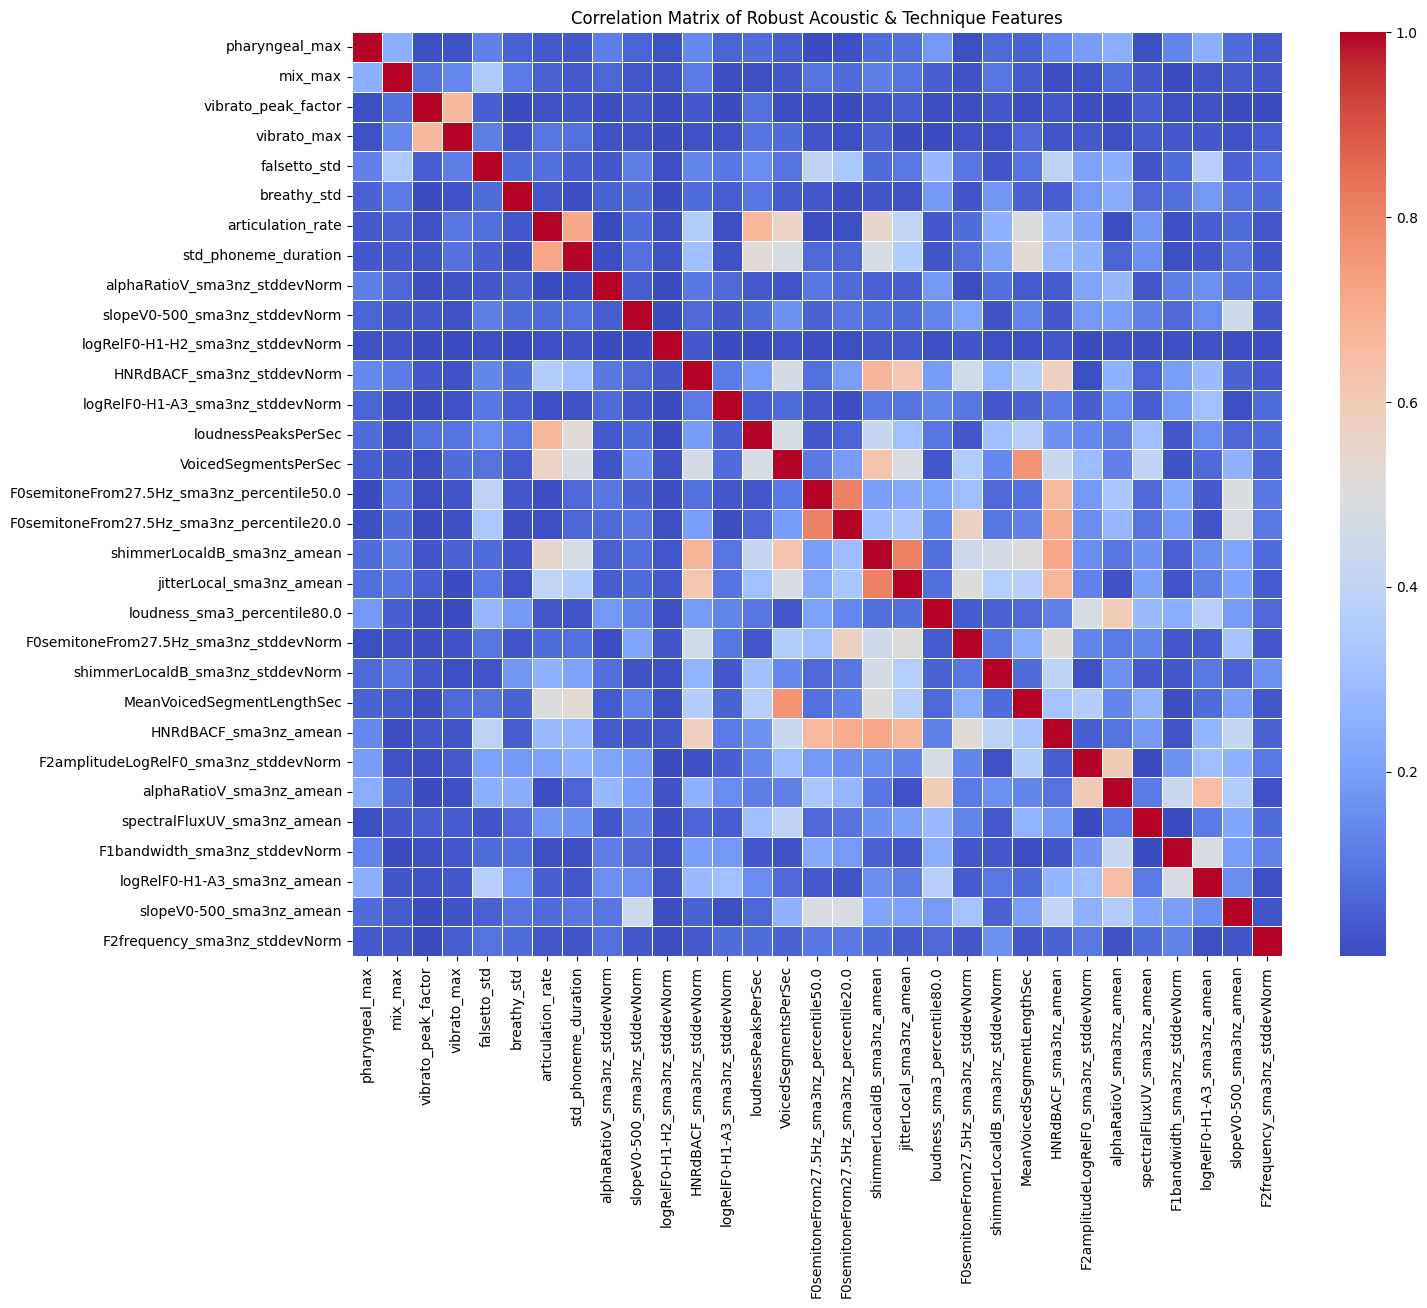

Pairs with high correlation (> 0.85):


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix only for the robust features
corr_matrix = df_gtsinger[all_feats].corr().abs()

# Heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Robust Acoustic & Technique Features')
plt.show()

# Locate pairs with high correlation (> 0.85)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print("Pairs with high correlation (> 0.85):")
for col in to_drop:
    # Βρίσκουμε με ποιο άλλο feature έχει συσχέτιση
    correlated_with = upper.index[upper[col] > 0.85].tolist()
    print(f"'{col}' is highly correlated with: {correlated_with}")

# what about both?

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score

def perform_loso_cross_validation(df, features_col, target_col, singer_id_col, wav_path_col):
    # Group by perfomance folder
    df['performance_folder'] = df[wav_path_col].apply(lambda x: os.path.dirname(x))

    X = df[features_col].values

    y = df[target_col].values
    groups = df[singer_id_col].values
    performance_ids = df['performance_folder'].values

    n_speakers = len(np.unique(groups))
    gkf = GroupKFold(n_splits=n_speakers)

    perf_accuracies = []
    all_final_preds = []
    all_final_actuals = []
    all_final_styles = [] # Νέα λίστα
    fold_balanced_accs = []
    fold_f1_scores = []

    print(f"LOSO Cross-Validation for {n_speakers} singer...")
    print(f"Calculating Majority Vote per Performance Folder...\n")

    fold = 1
    for train_idx, test_idx in gkf.split(X, y, groups=groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        test_performances = performance_ids[test_idx]

        model = RandomForestClassifier(
          n_estimators=200,
          max_depth=12,         # Higher depth
          min_samples_leaf=10,
          class_weight='balanced',
          random_state=42,
          max_features='sqrt'
      )
        model.fit(X_train, y_train)

        y_pred_segments = model.predict(X_test)

        unique_performances = np.unique(test_performances)
        correct_count = 0
        perf_preds_list = []
        perf_actuals_list = []

        for perf in unique_performances:
            idx = np.where(test_performances == perf)[0]
            perf_preds = y_pred_segments[idx]
            perf_actual = y_test[idx][0]
            style = df[df['performance_folder'] == perf]['singing_method'].iloc[0]

            # Majority Vote
            vals, counts = np.unique(perf_preds, return_counts=True)
            majority_val = vals[np.argmax(counts)]

            perf_preds_list.append(majority_val)
            perf_actuals_list.append(perf_actual)

            all_final_preds.append(majority_val)
            all_final_actuals.append(perf_actual)
            all_final_styles.append(style) # Αποθήκευση στυλ

            if majority_val == perf_actual:
                correct_count += 1

        fold_acc = (correct_count / len(unique_performances)) * 100
        perf_accuracies.append(fold_acc)

        f_bacc = balanced_accuracy_score(perf_actuals_list, perf_preds_list)
        f_f1 = f1_score(perf_actuals_list, perf_preds_list, average='macro')

        fold_balanced_accs.append(f_bacc * 100)
        fold_f1_scores.append(f_f1)

        current_singer = np.unique(groups[test_idx])[0]
        #print(f"Fold {fold} | Test Singer: {current_singer} | Acc: {fold_acc:.2f}%")
        print(f"Fold {fold} | Speaker: {current_singer} | Balanced Acc: {f_bacc*100:.2f}% | F1: {f_f1:.2f}")
        print(f"Detailed Classification Report for fold {fold}:")
        print(classification_report(perf_actuals_list, perf_preds_list))
        fold += 1

    print("\n" + "="*60)
    print(f"FINAL LOSO RESULTS (Majority Vote)")

    mean_bacc = np.mean(fold_balanced_accs)
    std_bacc = np.std(fold_balanced_accs)
    mean_f1 = np.mean(fold_f1_scores)

    print(f"Mean Balanced Accuracy (Per Speaker): {mean_bacc:.2f}%")
    print(f"Inter-Speaker Stability (STD): {std_bacc:.2f}%")
    print(f"Mean F1-score: {mean_f1:.2f}")
    print("="*60)

    # Global Balanced Accuracy
    global_balanced_acc = balanced_accuracy_score(all_final_actuals, all_final_preds)
    print(f"Global Balanced Accuracy: {global_balanced_acc*100:.2f}%")

    # Classification Report
    print("\nDetailed Classification Report (Global Aggregation):")
    print(classification_report(all_final_actuals, all_final_preds))
    return {
        "accuracies": perf_accuracies,
        "y_pred": all_final_preds,
        "y_true": all_final_actuals,
        "mean_acc": np.mean(perf_accuracies),
        "std_acc": np.std(perf_accuracies),
        'style': all_final_styles
    }

# comparison

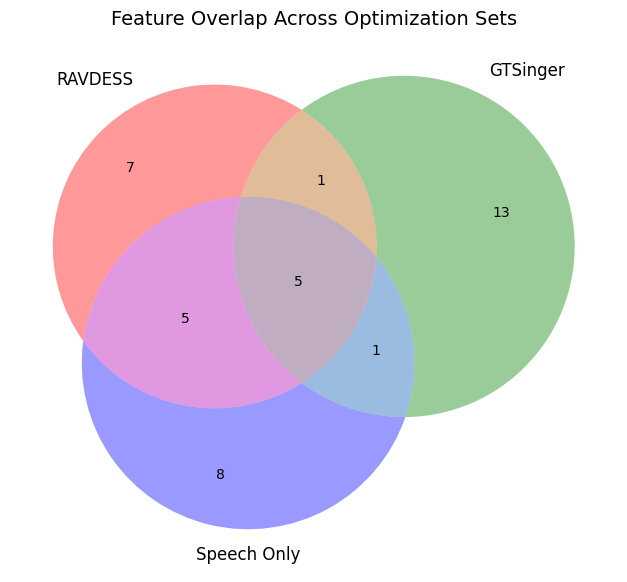

=== Common to ALL Sets (5) ===
• alphaRatioV_sma3nz_stddevNorm
• articulation_rate
• loudnessPeaksPerSec
• shimmerLocaldB_sma3nz_amean
• std_phoneme_duration

=== Common to GTSinger & Speech (but not RAVDESS) (1) ===
• MeanVoicedSegmentLengthSec

=== Common to GTSinger & RAVDESS (but not Speech) (1) ===
• pharyngeal_max

=== Common to GTSinger & Speech (but not GTSinger) (5) ===
• F0semitoneFrom27.5Hz_sma3nz_percentile80.0
• F0semitoneFrom27.5Hz_sma3nz_stddevNorm
• F2amplitudeLogRelF0_sma3nz_stddevNorm
• HNRdBACF_sma3nz_amean
• alphaRatioV_sma3nz_amean


In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

ravdess_set = set(expected_features)
gtsinger_set = set(selected_feats)
speech_set = set(expected_features_speech)
plt.figure(figsize=(10, 7))
# Δημιουργία Venn diagram για 3 sets
venn = venn3([ravdess_set, gtsinger_set, speech_set],
             set_labels=('RAVDESS', 'GTSinger', 'Speech Only'))

plt.title("Feature Overlap Across Optimization Sets", fontsize=14)
plt.show()

# Υπολογισμός τομών και μοναδικών στοιχείων
intersection_all = sorted(list(ravdess_set.intersection(gtsinger_set, speech_set)))
only_gtsinger = sorted(list(gtsinger_set - ravdess_set - speech_set))

print(f"=== Common to ALL Sets ({len(intersection_all)}) ===")
for feat in intersection_all:
    print(f"• {feat}")

# Προαιρετικά: Μπορείς να εκτυπώσεις και άλλες τομές αν χρειάζεσαι
# π.χ. κοινά GTSinger & Speech μόνο:
common_gs = sorted(list(gtsinger_set.intersection(speech_set) - ravdess_set))
print(f"\n=== Common to GTSinger & Speech (but not RAVDESS) ({len(common_gs)}) ===")
for feat in common_gs:
    print(f"• {feat}")

common_gr = sorted(list(gtsinger_set.intersection(ravdess_set) - speech_set))
print(f"\n=== Common to GTSinger & RAVDESS (but not Speech) ({len(common_gs)}) ===")
for feat in common_gr:
    print(f"• {feat}")

common_rs = sorted(list(speech_set.intersection(ravdess_set) - gtsinger_set))
print(f"\n=== Common to GTSinger & Speech (but not GTSinger) ({len(common_rs)}) ===")
for feat in common_rs:
    print(f"• {feat}")

In [ ]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

model_to_explain = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

# fit to all GTSinger data
X = df_gtsinger[selected_feats]
y = df_gtsinger['emotion']
model_to_explain.fit(X, y)


RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=20, n_estimators=200, random_state=42)

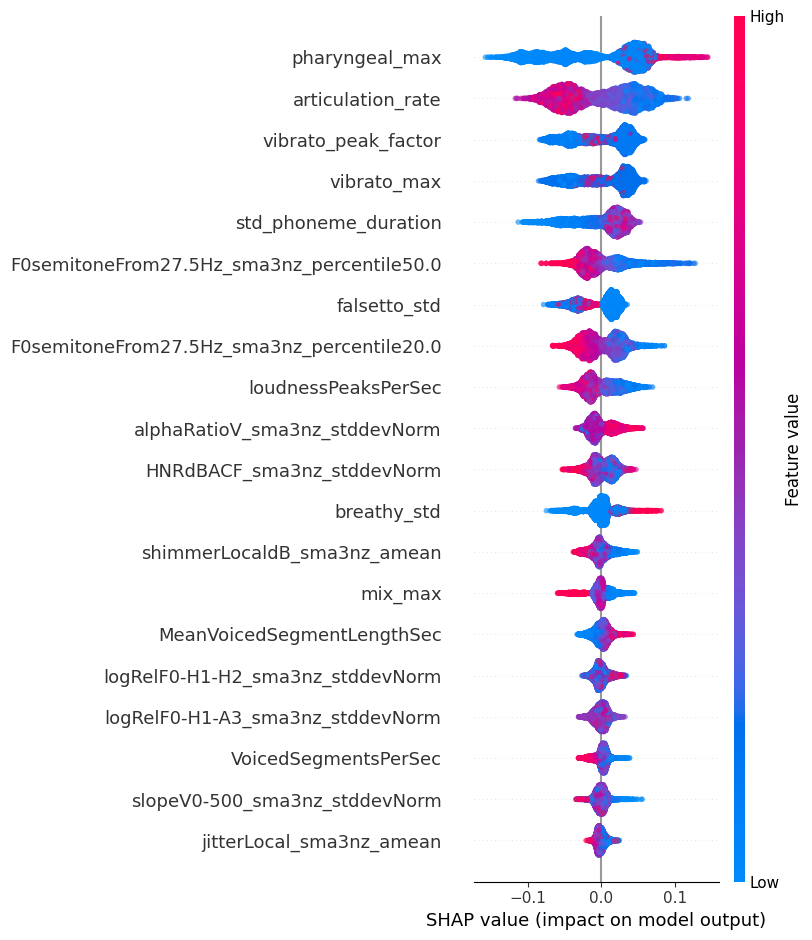

In [ ]:
# SHAP
explainer = shap.TreeExplainer(model_to_explain)
shap_values = explainer.shap_values(X)
shap_to_plot = shap_values[:, :, 1]
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_to_plot, X, plot_type="dot", alpha=0.6)

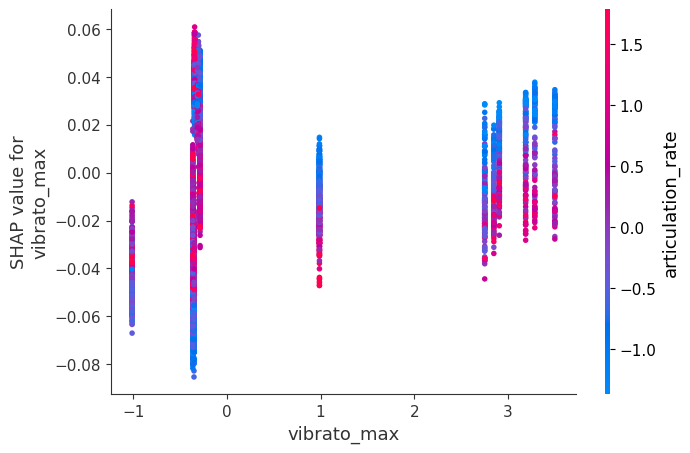

In [ ]:
import shap

# Dependence Plot for vibrato_std
# interaction_index='auto' will automatically find which feature vibrato_std
# is interacting with (has the strongest dependency)
shap.dependence_plot(
    "vibrato_max",
    shap_values[:, :, 1],
    X,
    interaction_index='auto'
)

# σε υψηλά επίπεδα vibrato, η υψηλή ταχύτητα άρθρωσης "σπρώχνει" την πρόβλεψη προς τα happy, ενω η χαμηλη ταχύτητα άρθωρσης "σπρώχνει" την πρόβλεψη προς sad

# test italian

In [ ]:
df_combined = pd.concat([df_gtsinger, df_italian], ignore_index=True, join='inner')

In [ ]:
df_combined.shape

(12498, 160)

In [ ]:
df_combined.isna().sum().sum()

np.int64(0)

## this is gtsinger selected

In [ ]:
results_gt = perform_loso_cross_validation(df_combined, selected_feats, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 10 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 56.78% | F1: 0.54
Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 57.51% | F1: 0.53
Fold 3 | Speaker: EN-Alto-2 | Balanced Acc: 62.06% | F1: 0.62
Fold 4 | Speaker: DE-Tenor-1 | Balanced Acc: 57.63% | F1: 0.57
Fold 5 | Speaker: FR-Tenor-1 | Balanced Acc: 52.18% | F1: 0.51
Fold 6 | Speaker: EN-Alto-1 | Balanced Acc: 51.98% | F1: 0.35
Fold 7 | Speaker: FR-Soprano-1 | Balanced Acc: 54.35% | F1: 0.32
Fold 8 | Speaker: IT-Bass-1 | Balanced Acc: 45.80% | F1: 0.28
Fold 9 | Speaker: IT-Bass-2 | Balanced Acc: 50.97% | F1: 0.43
Fold 10 | Speaker: IT-Soprano-1 | Balanced Acc: 72.33% | F1: 0.68

FINAL LOSO RESULTS (Majority Vote)
Mean Balanced Accuracy (Per Speaker): 56.16%
Inter-Speaker Stability (STD): 6.87%
Mean F1-score: 0.48
Global Balanced Accuracy: 60.82%

Detailed Classification Report (Global Aggregation):
              precision    recall  f1-score   supp

# this is speech selected

In [ ]:
results_sp = perform_loso_cross_validation(df_combined, expected_features_speech, 'emotion', 'unique_singer_id', 'wav_path')

LOSO Cross-Validation for 10 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 59.52% | F1: 0.59
Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 69.91% | F1: 0.69
Fold 3 | Speaker: EN-Alto-2 | Balanced Acc: 63.79% | F1: 0.60
Fold 4 | Speaker: DE-Tenor-1 | Balanced Acc: 59.45% | F1: 0.58
Fold 5 | Speaker: FR-Tenor-1 | Balanced Acc: 65.40% | F1: 0.54
Fold 6 | Speaker: EN-Alto-1 | Balanced Acc: 62.51% | F1: 0.60
Fold 7 | Speaker: FR-Soprano-1 | Balanced Acc: 50.91% | F1: 0.48
Fold 8 | Speaker: IT-Bass-1 | Balanced Acc: 42.28% | F1: 0.30
Fold 9 | Speaker: IT-Bass-2 | Balanced Acc: 35.28% | F1: 0.34
Fold 10 | Speaker: IT-Soprano-1 | Balanced Acc: 72.67% | F1: 0.39

FINAL LOSO RESULTS (Majority Vote)
Mean Balanced Accuracy (Per Speaker): 58.17%
Inter-Speaker Stability (STD): 11.33%
Mean F1-score: 0.51
Global Balanced Accuracy: 56.25%

Detailed Classification Report (Global Aggregation):
              precision    recall  f1-score   sup

# Undestanding Genre

In [ ]:
# 1. Run your function and save the dictionary output
results = perform_loso_cross_validation(df_gtsinger, selected_feats, 'emotion', 'unique_singer_id', 'wav_path')

# 2. Put the results into a Pandas DataFrame for easy filtering
res_df = pd.DataFrame({
    'y_true': results['y_true'],
    'y_pred': results['y_pred'],
    'style': results['style']
})

# 3. Analyze the predictions for each unique style
unique_styles = res_df['style'].unique()

print("\n" + "="*60)
print("PERFORMANCE BREAKDOWN BY SINGING STYLE")
print("="*60)

for s in unique_styles:
    print(f"\n Style: {s}")

    # Filter the dataframe for only this style
    subset = res_df[res_df['style'] == s]

    y_t = subset['y_true']
    y_p = subset['y_pred']

    # Calculate metrics
    # We use Balanced Accuracy to account for your Sad/Happy imbalance
    b_acc = balanced_accuracy_score(y_t, y_p)
    print(f"Total samples for {s}: {len(subset)}")
    print(f"Balanced Accuracy: {b_acc * 100:.2f}%\n")

    # Print the classification report to see exactly where the model fails
    # zero_division=0 prevents warnings if a model never predicted a certain class
    print(classification_report(y_t, y_p, zero_division=0))
    print("-" * 40)

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 62.41% | F1: 0.63
Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 61.90% | F1: 0.60
Fold 3 | Speaker: EN-Alto-2 | Balanced Acc: 62.78% | F1: 0.61
Fold 4 | Speaker: DE-Tenor-1 | Balanced Acc: 57.71% | F1: 0.58
Fold 5 | Speaker: FR-Tenor-1 | Balanced Acc: 57.80% | F1: 0.53
Fold 6 | Speaker: EN-Alto-1 | Balanced Acc: 61.02% | F1: 0.56
Fold 7 | Speaker: FR-Soprano-1 | Balanced Acc: 56.00% | F1: 0.50

FINAL LOSO RESULTS (Majority Vote)
Mean Balanced Accuracy (Per Speaker): 59.94%
Inter-Speaker Stability (STD): 2.51%
Mean F1-score: 0.57
Global Balanced Accuracy: 62.30%

Detailed Classification Report (Global Aggregation):
              precision    recall  f1-score   support

       happy       0.65      0.57      0.61       634
         sad       0.60      0.68      0.63       594

    accuracy                           0.62      1228
   macro avg       0.62

# this is ravdess selected

In [ ]:
# 1. Run your function and save the dictionary output
results = perform_loso_cross_validation(df_gtsinger, expected_features, 'emotion', 'unique_singer_id', 'wav_path')

# 2. Put the results into a Pandas DataFrame for easy filtering
res_df = pd.DataFrame({
    'y_true': results['y_true'],
    'y_pred': results['y_pred'],
    'style': results['style']
})

# 3. Analyze the predictions for each unique style
unique_styles = res_df['style'].unique()

print("\n")
print("PERFORMANCE BREAKDOWN BY SINGING STYLE")

for s in unique_styles:
    print(f"\n Style: {s}")

    # Filter the dataframe for only this style
    subset = res_df[res_df['style'] == s]

    y_t = subset['y_true']
    y_p = subset['y_pred']

    # Calculate metrics
    # We use Balanced Accuracy to account for your Sad/Happy imbalance
    b_acc = balanced_accuracy_score(y_t, y_p)
    print(f"Total samples for {s}: {len(subset)}")
    print(f"Balanced Accuracy: {b_acc * 100:.2f}%\n")

    # Print the classification report to see exactly where the model fails
    # zero_division=0 prevents warnings if a model never predicted a certain class
    print(classification_report(y_t, y_p, zero_division=0))
    print("-" * 40)

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 63.40% | F1: 0.62
Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 57.92% | F1: 0.54
Fold 3 | Speaker: EN-Alto-2 | Balanced Acc: 60.97% | F1: 0.60
Fold 4 | Speaker: DE-Tenor-1 | Balanced Acc: 58.93% | F1: 0.53
Fold 5 | Speaker: FR-Tenor-1 | Balanced Acc: 54.81% | F1: 0.55
Fold 6 | Speaker: EN-Alto-1 | Balanced Acc: 60.17% | F1: 0.49
Fold 7 | Speaker: FR-Soprano-1 | Balanced Acc: 57.87% | F1: 0.51

FINAL LOSO RESULTS (Majority Vote)
Mean Balanced Accuracy (Per Speaker): 59.15%
Inter-Speaker Stability (STD): 2.52%
Mean F1-score: 0.55
Global Balanced Accuracy: 60.10%

Detailed Classification Report (Global Aggregation):
              precision    recall  f1-score   support

       happy       0.63      0.55      0.59       634
         sad       0.58      0.65      0.61       594

    accuracy                           0.60      1228
   macro avg       0.60

# this is speech related

In [ ]:
# 1. Run your function and save the dictionary output
results = perform_loso_cross_validation(df_gtsinger, expected_features_speech, 'emotion', 'unique_singer_id', 'wav_path')

# 2. Put the results into a Pandas DataFrame for easy filtering
res_df = pd.DataFrame({
    'y_true': results['y_true'],
    'y_pred': results['y_pred'],
    'style': results['style']
})

# 3. Analyze the predictions for each unique style
unique_styles = res_df['style'].unique()

print("\n" + "="*60)
print("PERFORMANCE BREAKDOWN BY SINGING STYLE")
print("="*60)

for s in unique_styles:
    print(f"\n---> Style: {s} <---")

    # Filter the dataframe for only this style
    subset = res_df[res_df['style'] == s]

    y_t = subset['y_true']
    y_p = subset['y_pred']

    # Calculate metrics
    # We use Balanced Accuracy to account for your Sad/Happy imbalance
    b_acc = balanced_accuracy_score(y_t, y_p)
    print(f"Total samples for {s}: {len(subset)}")
    print(f"Balanced Accuracy: {b_acc * 100:.2f}%\n")

    # Print the classification report to see exactly where the model fails
    # zero_division=0 prevents warnings if a model never predicted a certain class
    print(classification_report(y_t, y_p, zero_division=0))
    print("-" * 40)

LOSO Cross-Validation for 7 singer...
Calculating Majority Vote per Performance Folder...

Fold 1 | Speaker: EN-Tenor-1 | Balanced Acc: 58.33% | F1: 0.58
Fold 2 | Speaker: DE-Soprano-1 | Balanced Acc: 68.72% | F1: 0.68
Fold 3 | Speaker: EN-Alto-2 | Balanced Acc: 64.65% | F1: 0.64
Fold 4 | Speaker: DE-Tenor-1 | Balanced Acc: 59.37% | F1: 0.60
Fold 5 | Speaker: FR-Tenor-1 | Balanced Acc: 70.92% | F1: 0.69
Fold 6 | Speaker: EN-Alto-1 | Balanced Acc: 61.86% | F1: 0.60
Fold 7 | Speaker: FR-Soprano-1 | Balanced Acc: 50.48% | F1: 0.50

FINAL LOSO RESULTS (Majority Vote)
Mean Balanced Accuracy (Per Speaker): 62.05%
Inter-Speaker Stability (STD): 6.38%
Mean F1-score: 0.61
Global Balanced Accuracy: 65.01%

Detailed Classification Report (Global Aggregation):
              precision    recall  f1-score   support

       happy       0.66      0.67      0.66       634
         sad       0.64      0.63      0.64       594

    accuracy                           0.65      1228
   macro avg       0.65